<a href="https://colab.research.google.com/github/MarinaNasser/SBE601-Numerical-ML-Action-Potentials/blob/main/Numerical_Techniques_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm  # Matrix exponential routine
from scipy.linalg import solve_banded
from scipy.integrate import solve_ivp
import scipy.sparse as sparse
import scipy.sparse.linalg as splinalg
from IPython.display import display
import time

#Hodgkin–Huxley and Fitzhugh–Nagumo (FHN) Models

**4.2 PDE Model**

The FHN PDE is

$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u) \qquad (4.1a)$$

where $a$ and $D$ are arbitrary constants with $0 \leq a \leq 1$, $D > 0$. Note, in particular, the cubic nonlinearity in $u$.

The following traveling wave solution to eq. (4.1) ([2], pp 166–171; [6], p4) is used to evaluate the numerical solution

$$u(x,t) = \frac{1}{1 + \exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]} \qquad (4.2a)$$

Eq. (4.2a) is used to specify the IC for eq. (4.1) at $t = 0$.

$$u(x,t = 0) = \frac{1}{1 + \exp\left[\frac{x}{\sqrt{2D}}\right]} \qquad (4.1b)$$

Also, boundary conditions (BCs) for eq. (4.1a) discussed subsequently include Neumann BCs that require the derivative $\partial u(x,t)/\partial x$. This derivative from eq. (4.2a) is

$$\frac{\partial u(x,t)}{\partial x} = \frac{-\exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]\frac{1}{\sqrt{2D}}}{\left\{1 + \exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]\right\}^2} \qquad (4.2b)$$

#Simulation parameters and exact solution at t=0

In [2]:
# ==========================================
# Simulation Parameters
# ==========================================
D = 1.0             # Diffusion coefficient
a = 0.25         # Threshold parameter, if a>=0.5 wave will  lose energy and collapse into a flat line (propagation failure).
nx = 400           # Number of spatial grid points
xl=-30
xu=30
x = np.linspace(xl, xu, nx)  # Spatial domain (centered around 0 to see the wave)
dx = x[1] - x[0]
tl=0
tu=130
t_span = (tl, tu)    # Simulate from t=tl to t=tu
t_eval = np.linspace(tl,tu,7)
nout=len(t_eval)

In [3]:
#Initial Condition (Exact Solution at t=0) ---
def exact_solution(x, t, D, a):
    term = x / np.sqrt(2 * D) + (a - 0.5) * t
    return 1.0 / (1.0 + np.exp(term))

In [4]:
print(f"t={t_eval}")

t=[  0.          21.66666667  43.33333333  65.          86.66666667
 108.33333333 130.        ]


In [5]:
# Initial Condition (Equation 4.1b)
u0 = exact_solution(x, 0, D, a)

# Case Definitions
cases = {
    1: "Analytical Dirichlet",
    2: "Constant Dirichlet",
    3: "Analytical Neumann",
    4: "Homogeneous Neumann",
    5: "No Boundary Conditions (Frozen)"
}

# Solving the 1D Single-Equation FHN Model using the Method of Lines (MOL)

The simplified, single-equation FitzHugh-Nagumo (FHN) model is a classic reaction-diffusion equation. It models the propagation of a traveling wave using a single scalar variable $u(x,t)$.

The continuous Partial Differential Equation (PDE) is given by:

$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u)$$

Where:
* $u(x,t)$ is the state variable (e.g., voltage or concentration).
* $D$ is the diffusion coefficient ($D > 0$).
* $a$ is the excitation threshold ($0 \leq a \leq 1$).
* $D\frac{\partial^2 u}{\partial x^2}$ is the spatial diffusion term.
* $-u(1 - u)(a - u)$ is the non-linear cubic reaction term.

The **Method of Lines (MOL)** solves this PDE by discretizing the spatial dimension ($x$) while leaving the time dimension ($t$) continuous. This transforms the single PDE into a large system of coupled Ordinary Differential Equations (ODEs).

### Step 1: Spatial Discretization
We divide the 1D continuous spatial domain into a grid of $N$ discrete nodes, separated by a uniform distance $\Delta x$.

Instead of searching for a continuous continuous surface $u(x,t)$, we now track a vector of continuous time-dependent variables $u_i(t)$, where $u_i$ represents the value of $u$ at the specific spatial coordinate $x_i$.

### Step 2: Approximating the Spatial Derivative
We must replace the continuous spatial derivative ($\frac{\partial^2 u}{\partial x^2}$) with an algebraic approximation. We use the standard second-order central finite difference method, which calculates the concavity at a node by looking at its immediate left and right neighbors:

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

### Step 3: Transforming into a System of ODEs
We substitute this spatial approximation back into the original PDE. The spatial derivative is mathematically eliminated, leaving us with an Ordinary Differential Equation strictly with respect to time for each internal node $i$:

$$\frac{du_i}{dt} = D \left( \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} \right) - u_i(1 - u_i)(a - u_i)$$

### Step 4: Applying Boundary Conditions
For the nodes at the very edges of the domain ($i=1$ and $i=N$), the finite difference formula cannot be applied directly because they lack a neighbor on one side.
* **Dirichlet Conditions:** If the boundaries are mathematically fixed at a constant value, their rate of change is zero: $\frac{du_1}{dt} = 0$ and $\frac{du_N}{dt} = 0$.
* **Neumann (Zero-Flux) Conditions:** If nothing can diffuse out of the domain, the slope at the boundary is zero. We use "ghost nodes" ($u_0 = u_2$) to modify the finite difference formula at the edges, ensuring the derivative remains zero.

### Conclusion
By applying this method across a grid of $N$ points, the original PDE problem is successfully converted into a system of $N$ coupled ODEs. You can now pass this system to any standard programmatic ODE solver to integrate forward through time and calculate the traveling wave.

 **BDF** / **Backward Differentiation Formula**.

In `scipy.integrate.solve_ivp`, **BDF** stands for **Backward Differentiation Formula**.


1. The Core Difference: Explicit vs. Implicit Methods

Most standard ODE solvers (like the default `RK45` in SciPy) are **explicit** methods. BDF is an **implicit** method.

* **Explicit Methods (e.g., RK45):** They calculate the *future* state of the system using only information from the *current* and *past* states.
* *The Math (Euler example):* $y_{t+1} = y_t + \Delta t \cdot f(t, y_t)$
* *The Vibe:* "I know my current speed and position, so I'll blindfold myself, walk forward for 1 second, and see where I end up."
* *Pros/Cons:* Computationally very fast per step, but prone to blowing up (becoming unstable) if the step size $\Delta t$ is too large.


* **Implicit Methods (e.g., BDF):** They calculate the future state by defining an equation that involves the *future state itself*, and then algebraically solving for it.
* *The Math (Backward Euler example):* $y_{t+1} = y_t + \Delta t \cdot f(t+1, \mathbf{y_{t+1}})$
* *The Vibe:* "I need to end up at a specific point in the future where the slope exactly points back to where I am right now."
* *Pros/Cons:* Requires solving a complex root-finding problem (like Newton's Method) at *every single time step*, making each step computationally expensive. However, it is **incredibly stable**, even with massive time steps.



**2. What is "Stiffness"?**

A system of ODEs is considered "stiff" when the equations dictate that the solution should be changing very slowly, but the underlying mathematical terms allow for extremely rapid, high-frequency oscillations.

If you use an explicit solver (RK45) on a stiff system, the solver will detect these microscopic, rapid changes and panic. To prevent the simulation from exploding to infinity (numerical instability), the solver will automatically shrink its time step $\Delta t$ to an astronomically small number. Your simulation might take weeks to compute a few seconds of simulated time.

**3. Why MOL creates massive Stiffness**

When we used the Method of Lines on the FitzHugh-Nagumo model, we approximated the diffusion term like this:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

Look closely at the denominator: $\Delta x^2$.
If we want a high-resolution simulation, we make $\Delta x$ very small (e.g., $0.01$).
Squaring that makes it even smaller ($0.0001$).
Because it is in the denominator, dividing by $0.0001$ acts as a massive multiplier ($10,000\times$) on the ODE.

This massive multiplier means that the spatial nodes are incredibly tightly coupled. If node $u_i$ changes by even a fraction of a decimal, the equations immediately try to violently pull $u_{i+1}$ and $u_{i-1}$ along with it.

**This tight spatial coupling creates severe mathematical stiffness.**

**Boundary Conditions in the 1D FHN Model (`ncase` selector)**

In the numerical solution of Partial Differential Equations (PDEs) using the Method of Lines (MOL), boundary conditions (BCs) dictate how the edges of the spatial domain behave. Without them, the spatial derivative approximations (like central finite differences) cannot be calculated at the very first and last grid points.

The `ncase` variable acts as a switch to apply five distinct boundary conditions to the 1D FitzHugh-Nagumo model. Here is a detailed breakdown of each case:

**`ncase = 1`: Analytical Dirichlet**

**Concept:** A Dirichlet boundary condition explicitly defines the *value* of the function at the boundary. "Analytical" means we force the boundaries to perfectly match the exact mathematical traveling wave solution at every time step.
**Mathematics:** $u(x_0, t) = u_{exact}(x_0, t)$ and $u(x_N, t) = u_{exact}(x_N, t)$
**Implementation:** The time derivative at the interior nodes is calculated normally using the PDE. However, the time derivatives at the boundary nodes ($\frac{du_0}{dt}$ and $\frac{du_N}{dt}$) are explicitly calculated using the derivative of the exact analytical solution (Eq 4.2a).
**Physical Meaning:** This forces the edges of your simulation grid to behave as if they are part of a perfect, infinite traveling wave, minimizing reflections or edge artifacts.
**Mathematical Implementation**
given the exact solution:

$$u(x,t) = \frac{1}{1 + \exp\left[\frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t\right]}$$

substitute the inner expression with a variable $z$:

$$z = \frac{x}{\sqrt{2D}} + \left(a - \frac{1}{2}\right)t$$

This simplifies the equation to:


$$u = (1 + e^z)^{-1}$$

Now, because Dirichlet boundaries fix the value of $u$ to the analytical solution at all times, the rate of change at the boundary ($\frac{\partial u}{\partial t}$) must equal the time derivative of this analytical solution. Using the **Chain Rule**, we differentiate with respect to $t$:

$$\frac{\partial u}{\partial t} = \frac{\partial u}{\partial z} \cdot \frac{\partial z}{\partial t}$$

1. **Differentiate $u$ with respect to $z$:**

$$\frac{\partial u}{\partial z} = -1 \cdot (1 + e^z)^{-2} \cdot e^z = -\frac{e^z}{(1 + e^z)^2}$$


2. **Differentiate $z$ with respect to $t$:**

$$\frac{\partial z}{\partial t} = \left(a - \frac{1}{2}\right) = (a - 0.5)$$



Multiplying them together gives the exact time derivative:


$$\frac{\partial u}{\partial t} = -\frac{e^z \cdot (a - 0.5)}{(1 + e^z)^2}$$

**`ncase = 2`: Constant Dirichlet**

**Concept:** This is a simpler Dirichlet condition where the boundary values are locked to specific constant numbers and never change over time.
**Mathematics:**
$u(x_0, t) = 1$ and $u(x_N, t) = 0$
**Implementation:** The time derivative for the interior nodes is calculated using the PDE. Because the boundaries are constant, their time derivatives are forced to zero: $\frac{du_0}{dt} = 0$ and $\frac{du_N}{dt} = 0$.
**Physical Meaning:** You are permanently pinning the left edge of the domain to a fully excited state (1) and the right edge to a resting state (0).

**`ncase = 3`: Analytical Neumann**

**Concept:** A Neumann boundary condition dictates the *slope* (spatial derivative) at the boundary, rather than the value itself. "Analytical" means we force the slope at the boundaries to match the exact mathematical slope of the traveling wave.
**Mathematics:**
$\frac{\partial u}{\partial x} \big|_{x_0, t} = \frac{\partial u_{exact}}{\partial x} \big|_{x_0, t}$
**Implementation:** We calculate the exact spatial derivative from the analytical solution (Eq 4.2b). We then use this exact slope to dynamically calculate the value of the "ghost nodes" outside our domain. These ghost nodes are fed into the central difference formula to calculate the second derivative at the boundaries. The PDE is then evaluated across the *entire* grid, allowing the actual boundary values to fluctuate.
**Physical Meaning:** Like Case 1, this attempts to simulate an infinite domain by perfectly matching the expected slope of the wave as it enters or leaves the simulation window.

**`ncase = 4`: Homogeneous Neumann (Zero-Flux)**
**Concept:** This states that the slope at the boundaries is exactly zero.
**Mathematics:**
$\frac{\partial u}{\partial x} \big|_{x_0, t} = 0$ and $\frac{\partial u}{\partial x} \big|_{x_N, t} = 0$
**Implementation:** To achieve a zero slope, the ghost node perfectly mirrors the first interior node ($u_{-1} = u_1$). When substituted into the finite difference formula for the boundary node, it simplifies to $u_{xx} = \frac{2(u_1 - u_0)}{\Delta x^2}$.
**Physical Meaning:** This represents an insulated boundary. No concentration or "voltage" can diffuse into or out of the domain. When a wave hits this boundary, it will not pass through; it will stop and potentially reflect.

**`ncase = 5`: Frozen Boundaries (No Applied BCs)**
**Concept:** In this specific code structure, Case 5 calculates the PDE for the interior points but explicitly sets the time derivatives of the boundaries to zero, without locking them to a predefined mathematical equation like in Case 1 or Case 2.
**Mathematics:**
$\frac{du_0}{dt} = 0$ and $\frac{du_N}{dt} = 0$
**Implementation:** It simply bypasses updating the boundaries. The boundary values will remain exactly what they were set to at $t=0$ (the initial conditions).
**Physical Meaning:** This is essentially a Constant Dirichlet condition, but instead of forcing arbitrary values like 1 and 0, it simply freezes the edges at whatever state they started in.

In [6]:
def fhn_pde(t, u, D, a, ncase, dx, x):
  """
    Evaluates the time derivative for the 1D FHN PDE with varying boundary conditions.

    Parameters:
    -----------
    t : float
        The current time step of the simulation.
    u : ndarray
        The current state vector values across the spatial grid.
    D : float
        Diffusion coefficient controlling spatial wave propagation.
    a : float
        Threshold parameter for the cubic reaction term u*(1-u)*(a-u).
    ncase : int
        Boundary condition selection flag:
        - 1: Analytical Dirichlet (Exact traveling wave)
        - 2: Constant Dirichlet (Left=1, Right=0)
        - 3: Analytical Neumann (Exact derivative slope)
        - 4: Homogeneous Neumann (Zero flux/slope)
        - 5: Frozen boundaries (t=0 values)
    dx : float
        Spatial step size (delta x) between grid points.
    x : ndarray
        Spatial grid coordinates corresponding to points in 'u'.

    Returns:
    --------
    dudt : ndarray
        The time derivative (du/dt) at each grid point, matching the shape of 'u'.
    """
  nx = len(u)
  dudt = np.zeros(nx)
  uxx = np.zeros(nx)

  # 1. Central difference for interior points
  uxx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2) #skip first and last elements

  # 2. Apply PDE and Boundary Conditions
  if ncase == 1:
      # Analytical Dirichlet: Boundaries are fixed to the exact traveling wave solution
      dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1]) #for interior points,replaced uxx with centered finite difference calculated before

      # Exact time-derivative of Eq 4.2a at boundaries
      term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * t
      dudt[0] = -np.exp(term_L) * (a - 0.5) / (1 + np.exp(term_L))**2

      term_R = x[-1] / np.sqrt(2*D) + (a - 0.5) * t
      dudt[-1] = -np.exp(term_R) * (a - 0.5) / (1 + np.exp(term_R))**2

  elif ncase == 2:
      # Constant Dirichlet: Left is fixed at 1, Right is fixed at 0 yeildng to zero dudt at the two ends
      dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])
      dudt[0] = 0.0
      dudt[-1] = 0.0

  elif ncase == 3:
      # Analytical Neumann: Slope at boundaries matches the exact derivative (Eq 4.2b)
      term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * t
      ux_L = -np.exp(term_L) * (1 / np.sqrt(2*D)) / (1 + np.exp(term_L))**2
      u_ghost_L = u[1] - 2 * dx * ux_L
      uxx[0] = (u[1] - 2 * u[0] + u_ghost_L) / (dx**2)

      term_R = x[-1] / np.sqrt(2*D) + (a - 0.5) * t
      ux_R = -np.exp(term_R) * (1 / np.sqrt(2*D)) / (1 + np.exp(term_R))**2
      u_ghost_R = u[-2] + 2 * dx * ux_R
      uxx[-1] = (u_ghost_R - 2 * u[-1] + u[-2]) / (dx**2)

      dudt = D * uxx - u * (1 - u) * (a - u)

  elif ncase == 4:
      # Homogeneous Neumann: Zero flux (slope is 0 at boundaries)
      uxx[0] = 2 * (u[1] - u[0]) / (dx**2) #u(-1)=u(1)
      uxx[-1] = 2 * (u[-2] - u[-1]) / (dx**2)
      dudt = D * uxx - u * (1 - u) * (a - u)

  elif ncase == 5:
      # No BCs applied / Boundaries frozen at t=0 values
      dudt[1:-1] = D * uxx[1:-1] - u[1:-1] * (1 - u[1:-1]) * (a - u[1:-1])
      dudt[0] = 0.0
      dudt[-1] = 0.0

  return dudt


In [7]:
# ==========================================
# Shared Helper Functions
# ==========================================


def solve_mol(t_span, t_eval, ncase, y0=None):
    """Solve the FHN PDE with the Method of Lines (implicit BDF solver).

    Returns
    -------
    (sol, elapsed) : the solve_ivp solution object and the wall-clock time
        (in seconds) the solve took.
    """
    if y0 is None:
        y0 = u0
    start_time = time.time()
    sol = solve_ivp(
        fun=fhn_pde,
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        args=(D, a, ncase, dx, x),
        method='BDF'  # BDF is excellent for stiff PDE problems
    )
    elapsed = time.time() - start_time
    return sol, elapsed


def ftcs_step_params(t_final_loc, safety=0.9):
    """CFL-limited explicit step size and the step count needed to reach
    t_final_loc: dt <= dx^2 / (2*D), using `safety` x the maximum allowed step."""
    dt_max = (dx**2) / (2.0 * D)
    dt_loc = dt_max * safety
    num_steps_loc = int(np.ceil(t_final_loc / dt_loc))
    return dt_loc, num_steps_loc


def run_ftcs(y0, dt_loc, num_steps_loc, ncase):
    """March the explicit FTCS scheme forward num_steps_loc steps.

    Returns
    -------
    (u_final, elapsed) : the final state vector and the wall-clock time
        (in seconds) the loop took.
    """
    start_time = time.time()
    u = y0.copy()
    for n in range(num_steps_loc):
        t_current = n * dt_loc
        # fhn_pde automatically applies the correct boundary conditions for ncase
        dudt = fhn_pde(t_current, u, D, a, ncase, dx, x)
        u = u + dt_loc * dudt
    elapsed = time.time() - start_time
    return u, elapsed


def run_ftcs_snapshots(y0, dt_loc, num_steps_loc, ncase, t_final_loc, n_snapshots=7):
    """March the explicit FTCS scheme forward, recording the wave profile
    (and the matching exact solution) every time a target snapshot time is
    crossed. The t=0 snapshot is handled by the caller, so this returns the
    remaining snapshots as a list of (t_label, u_snapshot, u_exact_snapshot).
    """
    t_snapshots = np.linspace(0, t_final_loc, n_snapshots)
    u = y0.copy()
    snapshot_idx = 1
    snapshots = []
    for n in range(num_steps_loc):
        t_current = n * dt_loc
        dudt = fhn_pde(t_current, u, D, a, ncase, dx, x)
        u = u + dt_loc * dudt
        u_exact_current = exact_solution(x, t_current, D, a)

        # Check if the simulation has crossed the next target snapshot time
        if snapshot_idx < n_snapshots and (n + 1) * dt_loc >= t_snapshots[snapshot_idx]:
            snapshots.append(((n + 1) * dt_loc, u.copy(), u_exact_current))
            snapshot_idx += 1
    return snapshots


def print_execution_time_summary(mol_times, fdm_times):
    avg_mol_time = np.mean(mol_times)
    avg_fdm_time = np.mean(fdm_times)

    print("\n" + "="*50)
    print("EXECUTION TIME SUMMARY")
    print("="*50)
    for ncase in range(1, 6):
        print(f"Case {ncase} ({cases[ncase]:<20}): MOL = {mol_times[ncase-1]:.4f}s  |  FDM = {fdm_times[ncase-1]:.4f}s")
    print("-" * 50)
    print(f"AVERAGE MOL TIME: {avg_mol_time:.4f} seconds")
    print(f"AVERAGE FDM TIME: {avg_fdm_time:.4f} seconds")
    print("="*50)


###MOL Results

Solving Case 1: Analytical Dirichlet...
Solving Case 2: Constant Dirichlet...
Solving Case 3: Analytical Neumann...
Solving Case 4: Homogeneous Neumann...
Solving Case 5: No Boundary Conditions (Frozen)...


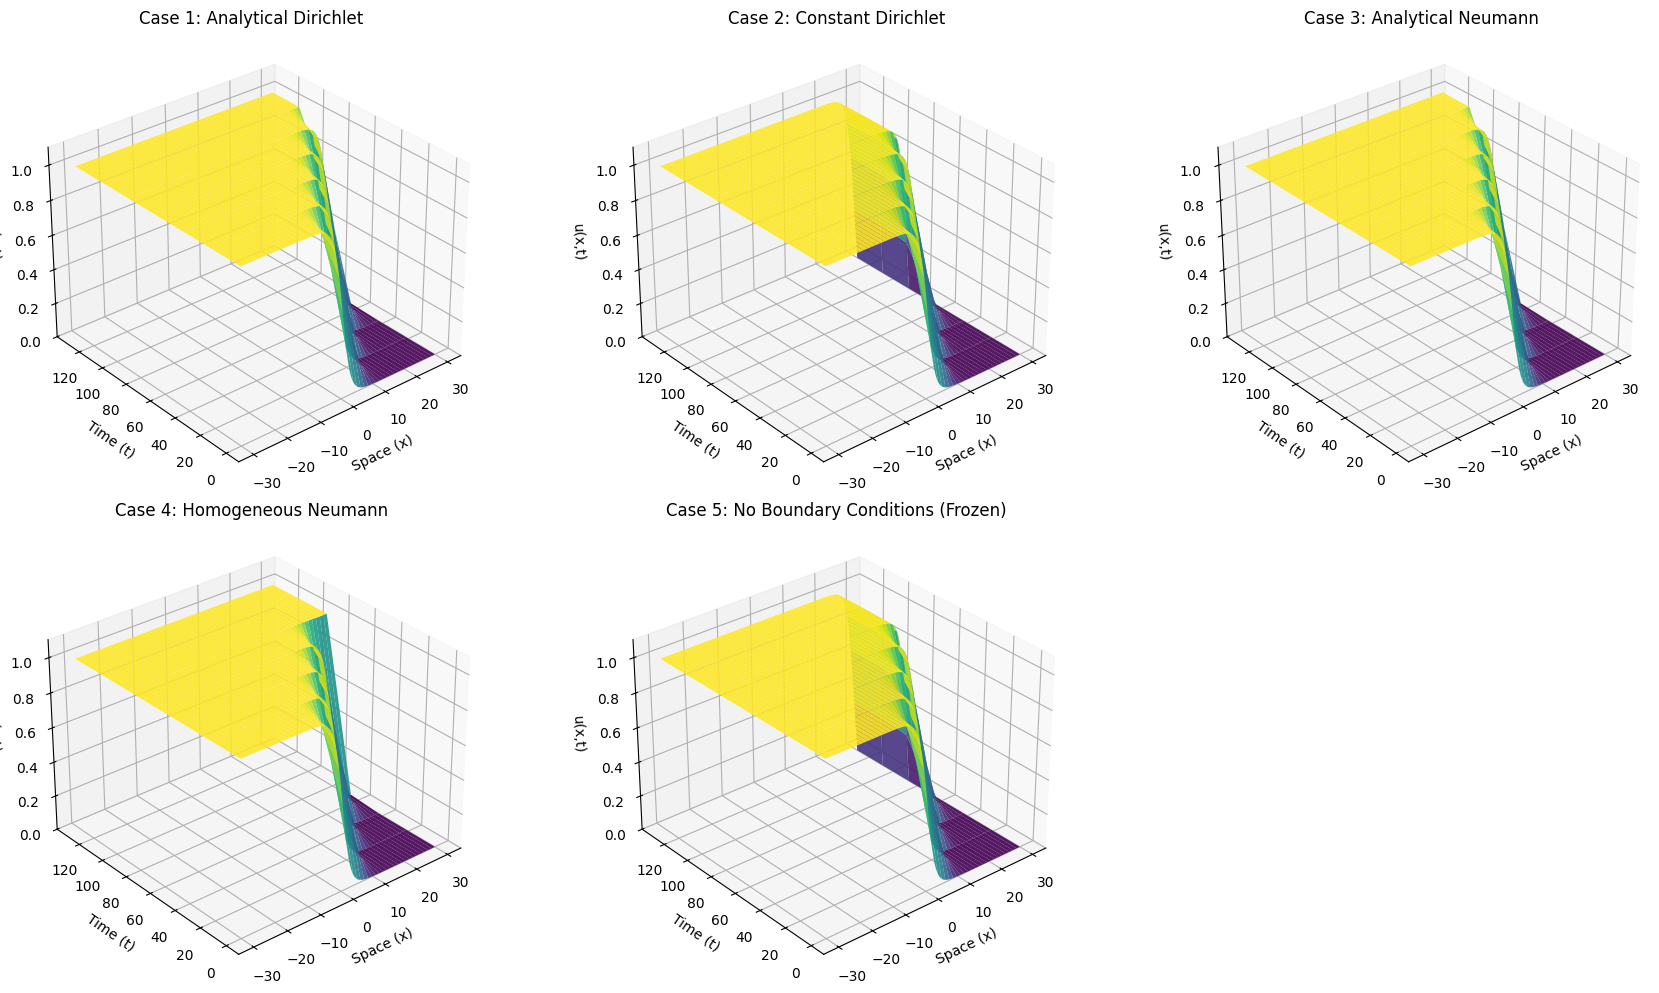

In [8]:
ua_plot = np.zeros((nx, len(t_eval)))
for it in range(len(t_eval)):
    ua_plot[:, it] = exact_solution(x, t_eval[it], D, a)

# ==========================================
# Run Solver & Plotting Loop
# ==========================================
fig = plt.figure(figsize=(18, 10))

for ncase, title in cases.items():
    print(f"Solving Case {ncase}: {title}...")

    # Solve the ODE system
    sol, _ = solve_mol(t_span, t_eval, ncase)

    # Prepare data for 3D plot
    T, X = np.meshgrid(sol.t, x)
    U = sol.y # The solution matrix

    # Create 3D Subplot
    ax = fig.add_subplot(2, 3, ncase, projection='3d')
    surf = ax.plot_surface(X, T, U, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title(f"Case {ncase}: {title}")
    ax.set_xlabel("Space (x)")
    ax.set_ylabel("Time (t)")
    ax.set_zlabel("u(x,t)")
    ax.set_zlim(0, 1.1)

    # Adjust viewing angle for better visibility
    ax.view_init(elev=30, azim=230)

plt.tight_layout()
plt.show()

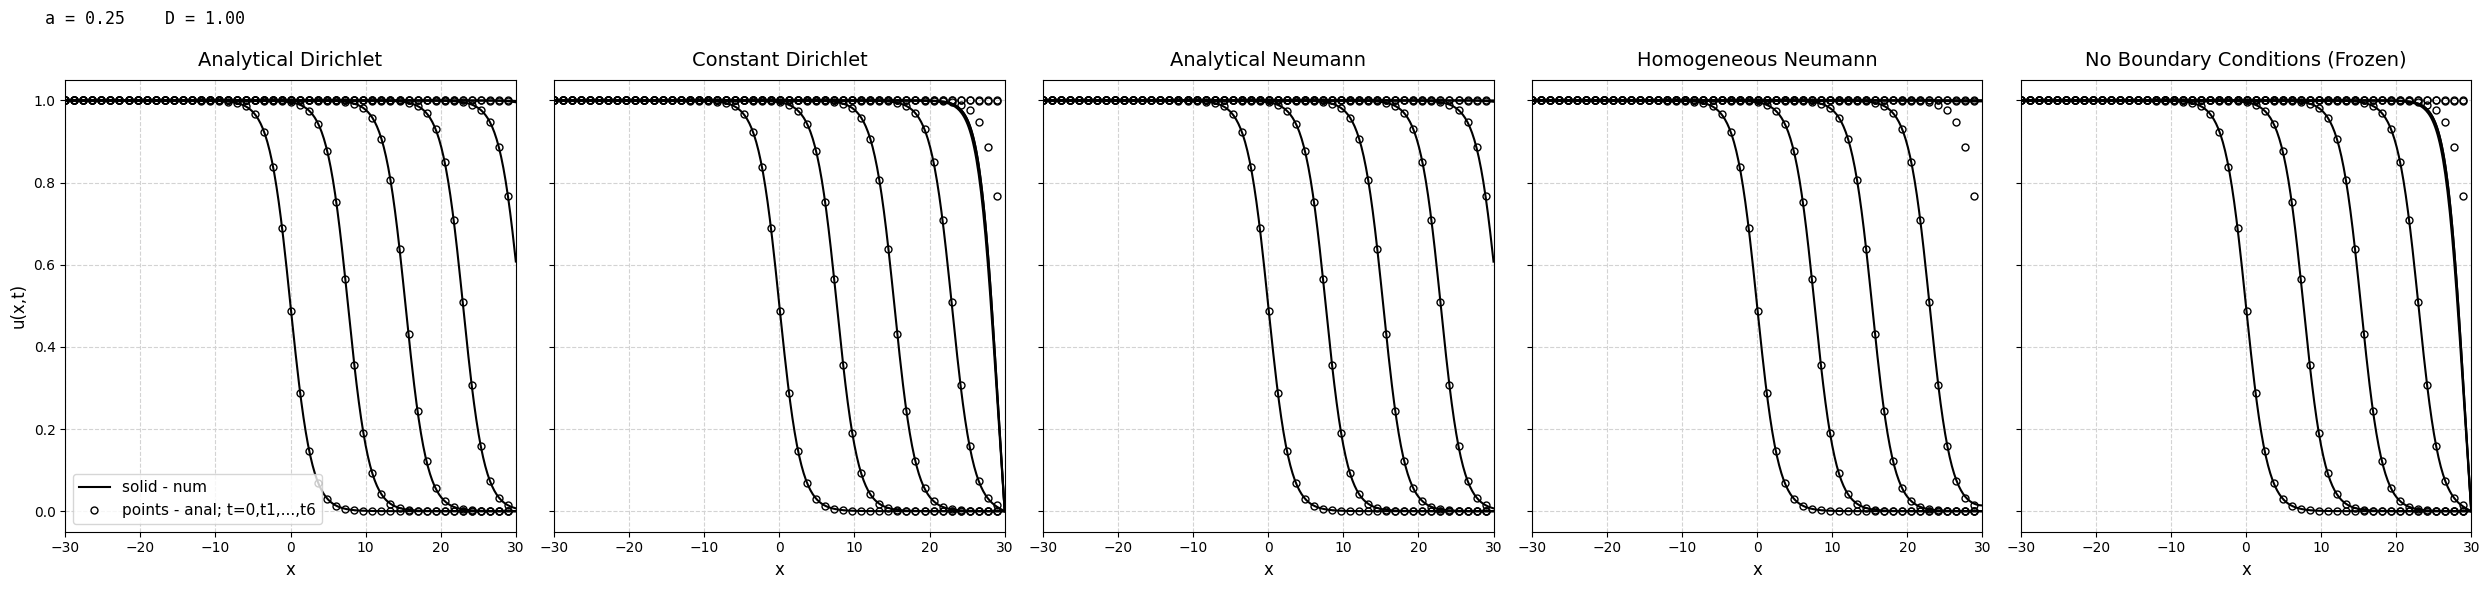

In [9]:
# Create a 5-panel wide figure
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharey=True)

# Subsample index for the open circles so they don't overlap into a solid line
marker_stride = 8

# Add the parameter text to the top left of the figure (like your image)
fig.text(0.02, 0.95, f"a = {a:.2f}    D = {D:.2f}", fontsize=12, family='monospace')

for ncase in range(1, 6):
    ax = axes[ncase - 1]

    # Solve the PDE for the current case
    sol, _ = solve_mol(t_span, t_eval, ncase)

    # Plot each time step
    for i, t_val in enumerate(t_eval):
        # 1. Numerical Solution (Solid Black Line)
        num_label = "solid - num" if i == 0 else ""
        ax.plot(x, sol.y[:, i], 'k-', label=num_label)

        # 2. Analytical Reference (Open Circles)
        u_anal = exact_solution(x, t_val, D, a)
        anal_label = "points - anal; t=0,t1,...,t6" if i == 0 else ""
        ax.plot(x[::marker_stride], u_anal[::marker_stride], 'ko',
                mfc='none', markersize=5, label=anal_label)

    # Formatting exactly like the uploaded image
    ax.set_title(cases[ncase], fontsize=14, pad=10)
    ax.set_xlabel("x", fontsize=12)
    ax.set_xlim([xl, xu])
    ax.set_ylim([-0.05, 1.05])

    # Light gray dashed grid
    ax.grid(True, linestyle="--", color="lightgray")

    # Add y-axis label and legend only to the first plot to avoid clutter
    if ncase == 1:
        ax.set_ylabel("u(x,t)", fontsize=12)
        ax.legend(loc="lower left", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93]) # Leave space at top for the parameter text
plt.show()

**Explaination of the above figure**

choosing a simulation duration of $t=130$, the wave  reached the right boundary
($x = 30$), and you can clearly see the boundary conditions completely changing the behavior of the wave!

Here is the physical and mathematical explanation for exactly what is happening at the right boundary in each of the five subplots:

**1. Analytical Dirichlet (Far Left)**

* **What you see:** The solid black lines perfectly overlap the open circles (the exact mathematical solution) at all times. The wave smoothly exits the right side of the screen as if the boundary wasn't even there.
* **Why it happens:** This boundary condition constantly calculates the exact theoretical value of the wave at $x=30$ for every given second and forces the edge point to equal that value. Because it cheats by looking at the exact answer, it naturally produces a perfect, error-free exit.

**2. Constant Dirichlet (Center Left)**

* **What you see:** As the wave reaches the right edge, the top part of the wave gets "squashed" downward. The line is forced to hit $0$ at the exact edge, creating a very steep, unnatural artificial slope.
* **Why it happens:** A Constant Dirichlet condition acts like a pinned string. Your code explicitly dictates `dudt[-1] = 0.0` and initially the edge is at $0$. Therefore, no matter how much the traveling wave tries to pull that edge point up to $1.0$, the boundary is clamped at exactly $0$.

**3. Analytical Neumann (Center)**

* **What you see:** Just like Case 1, the numerical wave smoothly follows the analytical circles and exits the domain beautifully without distorting.
* **Why it happens:** Instead of fixing the *value* (Dirichlet), this condition fixes the *slope* (Neumann). Your code calculates exactly what the slope $\left(\frac{\partial u}{\partial x}\right)$ of the theoretical wave should be as it passes through the boundary, and dynamically bends the edge of your grid to match that slope. This allows the wave to naturally "flow" out of the domain.

**4. Homogeneous Neumann (Center Right)**

* **What you see:** As the wave hits the right edge, it "piles up." Instead of dipping down to 0, the leading edge flattens out horizontally at the wall, and the value of $u$ at the boundary rises all the way to $1.0$.
* **Why it happens:** This is the **"Zero Flux"** or insulated wall condition. Mathematically, you forced the slope at the edge to be exactly zero (completely flat). Physically, this means nothing is allowed to leave the domain. Because the wave's mass cannot exit through the boundary, it crashes into the wall and levels off, completely filling the space.

**5. No Boundary Conditions / Frozen (Far Right)**

* **What you see:** The right boundary looks completely identical to Case 2 (Constant Dirichlet). The wave gets squashed down to $0$ at the edge.
* **Why it happens:** This case locks the boundary to whatever value it had at the very first frame ($t=0$). At $t=0$, the wave was centered near $x=0$, meaning the value way out at $x=30$ was practically $0$. Because it is frozen at that initial state, it acts exactly like a clamped Constant Dirichlet boundary pinned at $0$.

# Fundamentals of the Fully Discrete Finite Difference Method (FDM) (Applying to the FHN Model)

**FTCS** stands for **Forward-Time Central-Space**. It is a fundamental explicit finite difference method used to solve time-dependent Partial Differential Equations (PDEs).

While often taught using simple heat diffusion, it can easily be applied to non-linear reaction-diffusion systems like the simplified 1D FitzHugh-Nagumo (FHN) model. Here is a complete breakdown of how FTCS discretizes and solves this specific equation.

---

## 1. The Mathematical Problem
The simplified 1D FHN model tracks a single variable (like voltage) propagating through a medium:

$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} - u(1 - u)(a - u)$$

Where:
* $u(x,t)$ is the state variable.
* $D$ is the diffusion coefficient.
* $a$ is the threshold parameter.
* $D\frac{\partial^2 u}{\partial x^2}$ is the spatial diffusion term.
* $-u(1-u)(a-u)$ is the non-linear reaction term.

## 2. Discretizing Space and Time
Computers cannot solve continuous functions directly. We must chop space and time into a discrete grid:
* **Space ($x$):** Divided into discrete nodes separated by a constant distance $\Delta x$. We use the subscript $i$ to denote spatial position (e.g., $x_i$).
* **Time ($t$):** Divided into discrete steps separated by a constant duration $\Delta t$. We use the superscript $n$ to denote the time step (e.g., $t^n$).

Therefore, the exact value of our wave at a specific point in space and time is written as: **$u_i^n$**

## 3. The Core Approximations
The name "FTCS" dictates exactly how we approximate the derivatives.

### A. Forward-Time (FT)
We approximate the time derivative ($\frac{\partial u}{\partial t}$) using a **Forward Euler** difference. We look at the difference between the *current* time step ($n$) and the *future* time step ($n+1$):

$$\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}$$

### B. Central-Space (CS)
We approximate the spatial diffusion derivative ($\frac{\partial^2 u}{\partial x^2}$) using a **Central** difference. We look at the node's immediate neighbors to the left ($i-1$) and right ($i+1$) exactly as they are at the *current* time step ($n$):

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

## 4. Constructing the FTCS Equation
We substitute these approximations back into the continuous FHN equation. Note that the non-linear reaction term is simply evaluated at the current, known state ($u_i^n$):

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = D \left( \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2} \right) - u_i^n(1 - u_i^n)(a - u_i^n)$$

Because the goal is to predict the future, we algebraically isolate the future term ($u_i^{n+1}$) on the left side:

$$u_i^{n+1} = u_i^n + \frac{D \Delta t}{\Delta x^2} \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right) - \Delta t \big[ u_i^n(1 - u_i^n)(a - u_i^n) \big]$$

To make the math cleaner and track stability, we bundle the diffusion constants into a dimensionless number called the **Fourier Number** (or grid parameter), denoted as $r$:

$$r = \frac{D \Delta t}{\Delta x^2}$$

This gives us the final, highly elegant FTCS algebraic update equation:

$$u_i^{n+1} = r u_{i+1}^n + (1 - 2r)u_i^n + r u_{i-1}^n - \Delta t \big[ u_i^n(1 - u_i^n)(a - u_i^n) \big]$$

---

## 5. How the Algorithm Works in Practice
This equation reveals the simplicity of the explicit FTCS method. To find the exact state of a node in the next time step, you only need to know its current state and the current state of its two immediate neighbors.

Here is the loop a computer runs:
1. **Initialize:** Define the starting values $u_i^0$ for all spatial nodes at $t=0$.
2. **Apply Boundaries:** Set the values at the far left and right edges (e.g., using ghost nodes for Zero-Flux).
3. **Time Loop:** Begin stepping forward by $\Delta t$.
4. **Space Loop:** At each time step, loop through every internal node $i$. Apply the FTCS equation to calculate $u_i^{n+1}$ using only the known values from the current array $u^n$.
5. **Overwrite and Repeat:** Once the entire future array $u^{n+1}$ is calculated, overwrite $u^n$ with it, and repeat the loop.

---

## 6. The Fatal Flaw: Stability Limits
Because FTCS is an **explicit** method (it calculates the future blindly without cross-checking for physical constraints), it is highly prone to numerical instability.

The middle diffusion term of the FTCS equation: **$(1 - 2r)u_i^n$**

If $r > 0.5$, the coefficient $(1 - 2r)$ becomes negative. This physically implies that an excited, high-value node will cause itself to violently drop into a negative state in the very next instant. This triggers wild mathematical oscillations that instantly explode to infinity.

Therefore, you must strictly obey the Courant-Friedrichs-Lewy (CFL) stability criterion for the diffusion term:

$$r \le \frac{1}{2} \implies \Delta t \le \frac{\Delta x^2}{2D}$$

*Note: In reaction-diffusion systems like FHN, the non-linear reaction term can sometimes impose an even stricter limit on $\Delta t$ to prevent the cubic multiplier from blowing up, but the diffusion CFL limit is almost always the primary bottleneck that forces FTCS to take thousands of tiny time steps.*

##Fully Discrete Finite Difference Method (FDM) VS Method of Lines(MOL)

####FDM Setup

In [10]:
import time
#---------------------------------------------
# FDM Setup
#---------------------------------------------

# Simulation time
t_final = 20
dt, num_steps = ftcs_step_params(t_final)  # dt = 90% of max allowed step for safety



### FDM Vs MOL with (Homogenous Neumann BC ,zero flux at the boundaries)

Starting MOL (Implicit BDF)...
Starting MOL (Implicit BDF) with zero flus initial conditions
MOL finished in: 0.0532 seconds (Took 2 time steps)

Starting Fully Discrete FDM (Explicit FTCS)...
FTCS finished in: 0.0433 seconds (Took 1966 time steps)


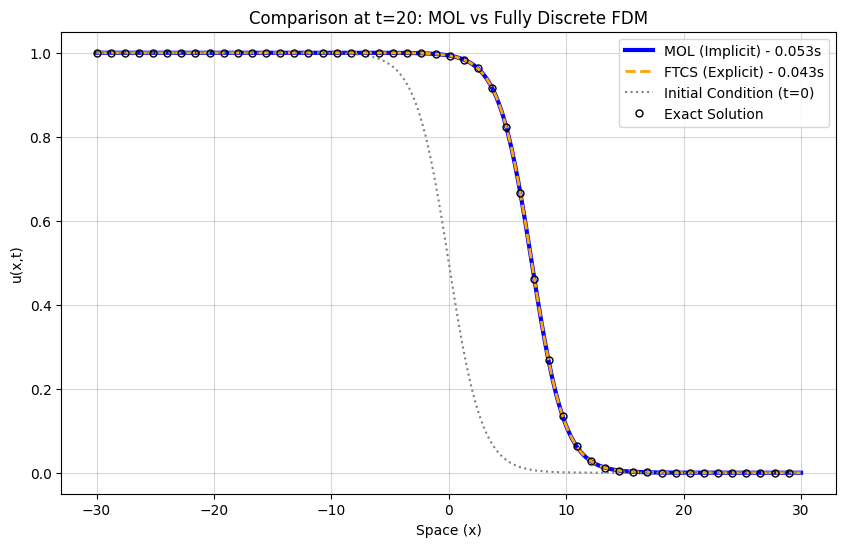

In [11]:
# ==========================================
# MOL with Implicit BDF
# ==========================================
print("Starting MOL (Implicit BDF)...")
# ==========================================
# MOL with Implicit BDF with zero flux BC
# ==========================================

print("Starting MOL (Implicit BDF) with zero flus initial conditions")

mol_sol, mol_time = solve_mol((0, t_final), (0, t_final), 4)  # Homogenous Neumann BC
u_mol_final = mol_sol.y[:, -1]
print(f"MOL finished in: {mol_time:.4f} seconds (Took {len(mol_sol.t)} time steps)")

# ==========================================
# Method 2: Fully Discrete FDM (Explicit FTCS)
# ==========================================
print("\nStarting Fully Discrete FDM (Explicit FTCS)...")

u_ftcs, ftcs_time = run_ftcs(u0, dt, num_steps, 4)  # Homogenous Neumann BC
print(f"FTCS finished in: {ftcs_time:.4f} seconds (Took {num_steps} time steps)")

#Exact solution
u_exact_final = exact_solution(x, t_final, D, a)

# ==========================================
# Plot Comparison
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(x, u_mol_final, '-', linewidth=3, label=f'MOL (Implicit) - {mol_time:.3f}s', color='blue')
plt.plot(x, u_ftcs, '--', linewidth=2, label=f'FTCS (Explicit) - {ftcs_time:.3f}s', color='orange')
plt.plot(x, u0, ':', color='grey', label='Initial Condition (t=0)')
plt.plot(x, u_exact_final, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

plt.title(f'Comparison at t={t_final}: MOL vs Fully Discrete FDM')
plt.xlabel('Space (x)')
plt.ylabel('u(x,t)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


###FDM VS MOL for each boundary condition

Starting simulations...

Processing Case 1: Analytical Dirichlet...
Processing Case 2: Constant Dirichlet...
Processing Case 3: Analytical Neumann...
Processing Case 4: Homogeneous Neumann...
Processing Case 5: No Boundary Conditions (Frozen)...


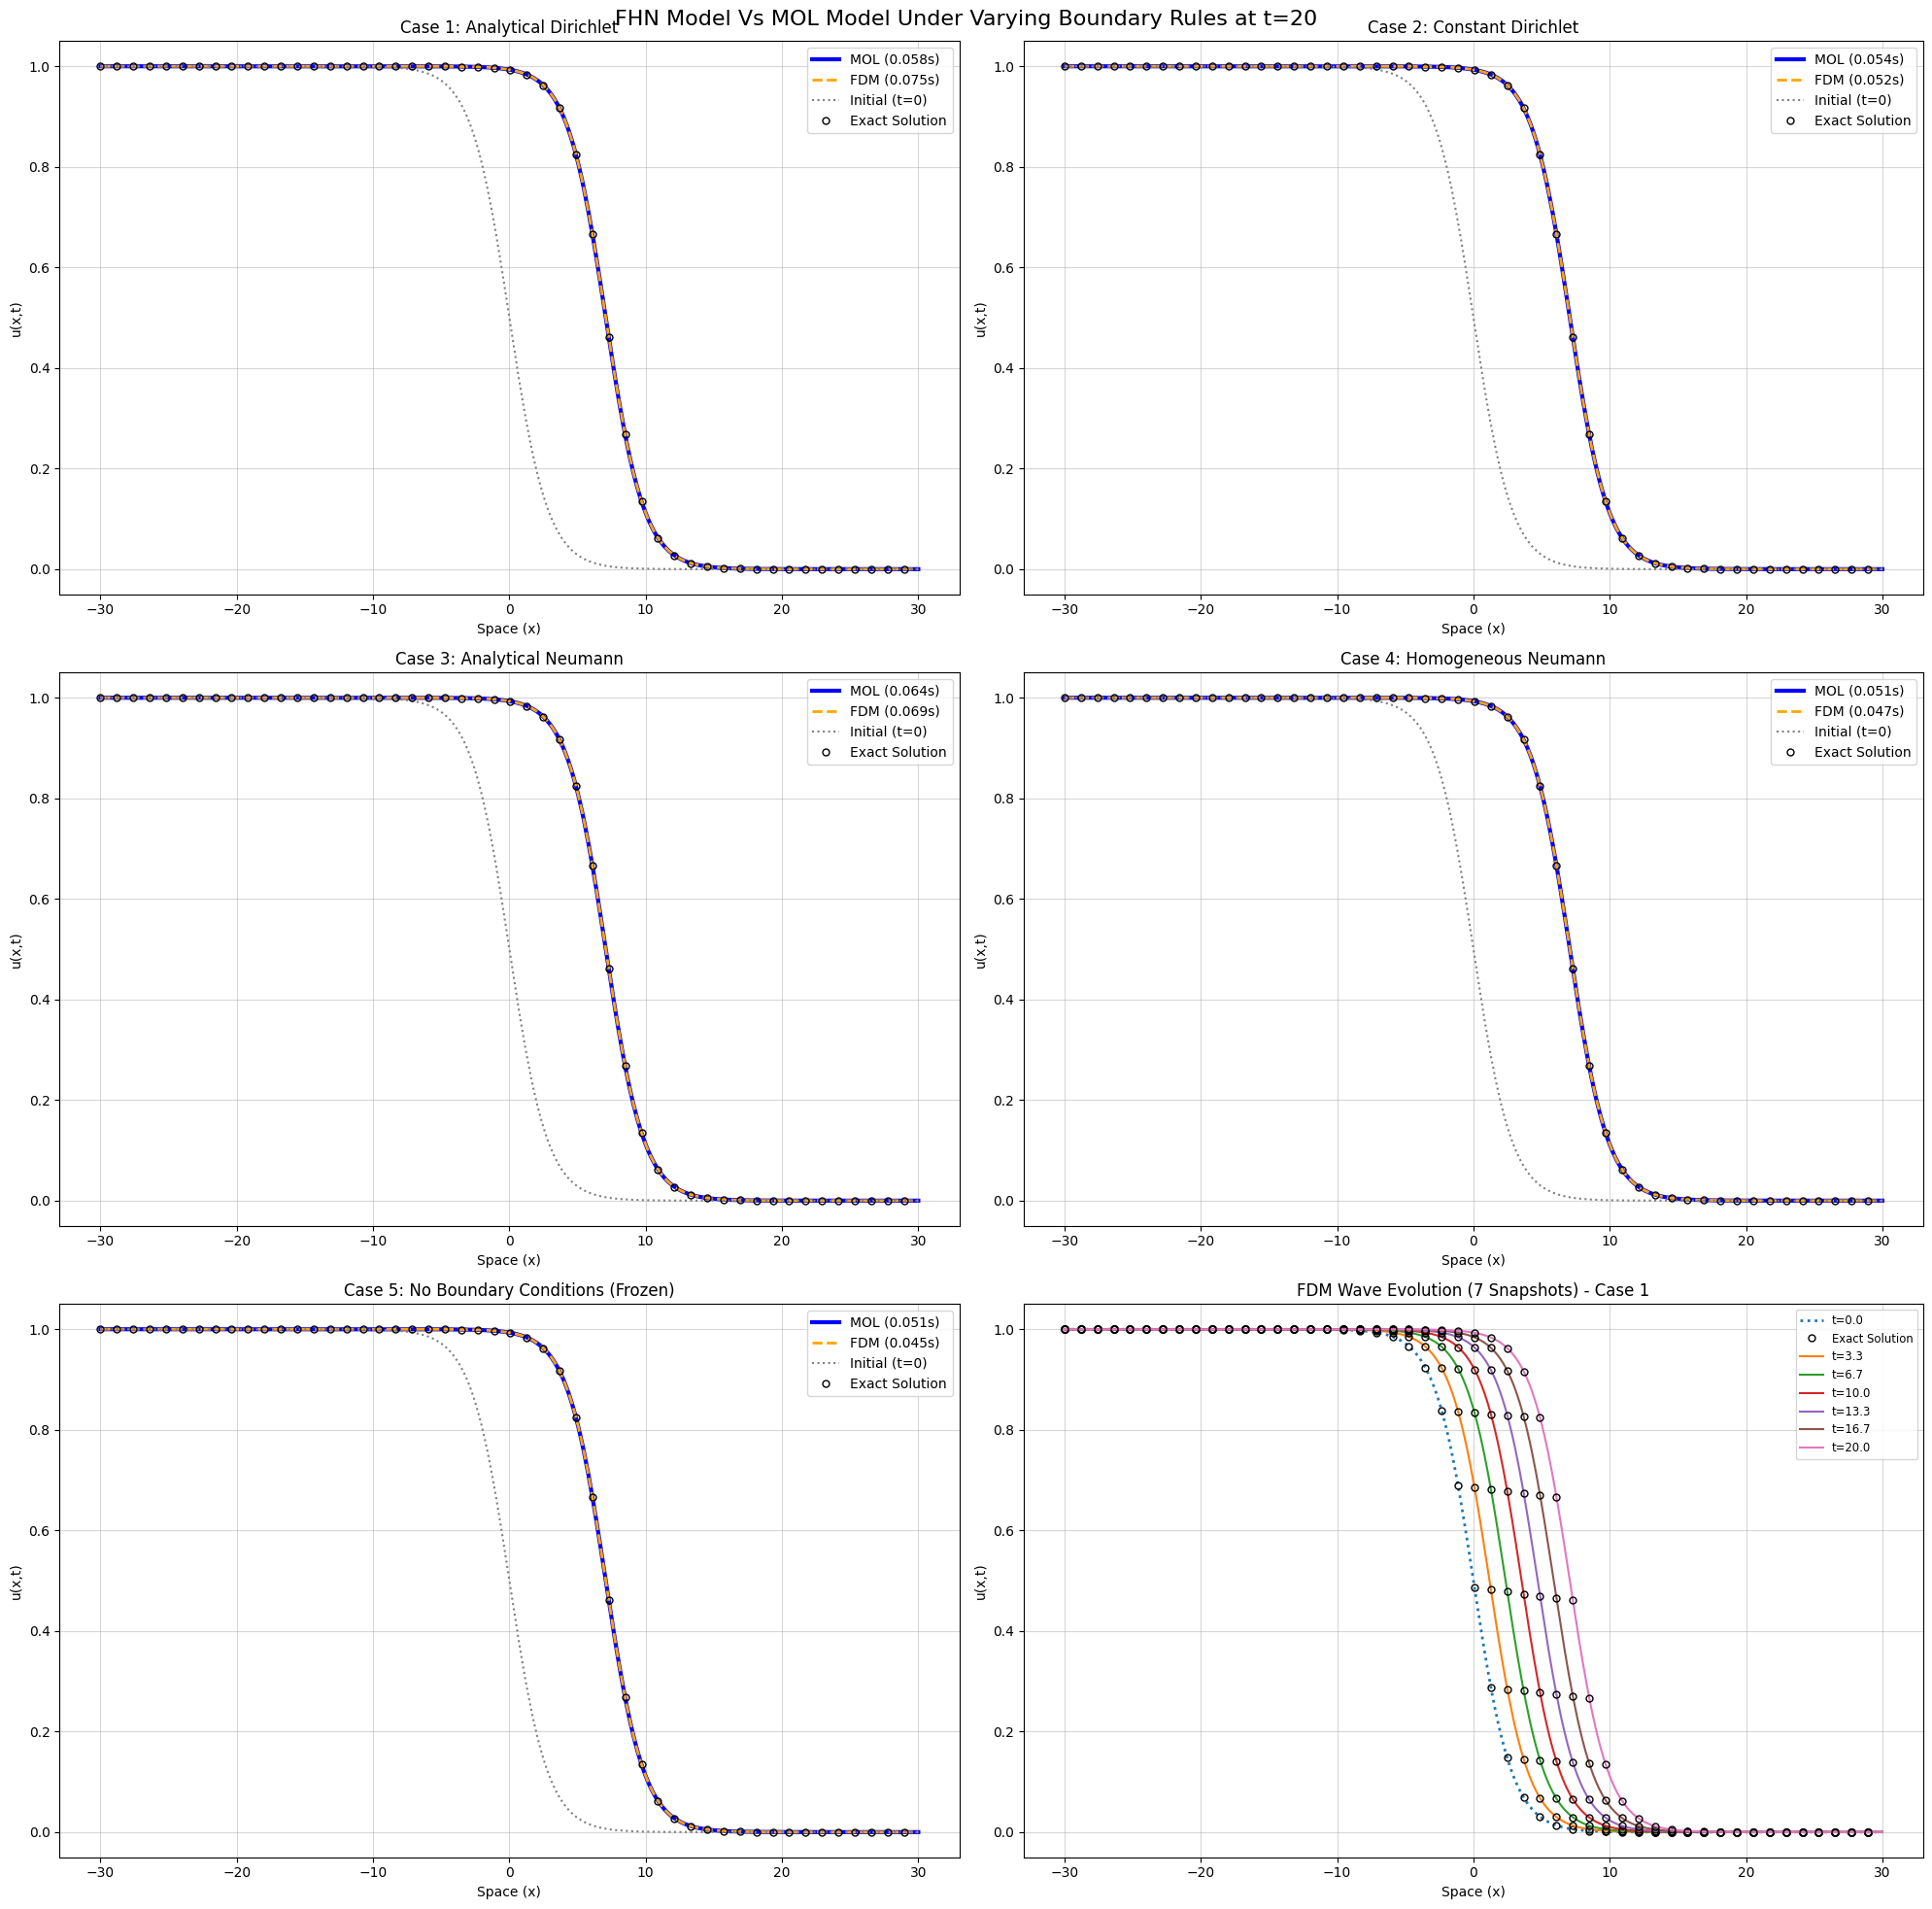


EXECUTION TIME SUMMARY
Case 1 (Analytical Dirichlet): MOL = 0.0575s  |  FDM = 0.0753s
Case 2 (Constant Dirichlet  ): MOL = 0.0539s  |  FDM = 0.0515s
Case 3 (Analytical Neumann  ): MOL = 0.0641s  |  FDM = 0.0688s
Case 4 (Homogeneous Neumann ): MOL = 0.0510s  |  FDM = 0.0470s
Case 5 (No Boundary Conditions (Frozen)): MOL = 0.0507s  |  FDM = 0.0451s
--------------------------------------------------
AVERAGE MOL TIME: 0.0555 seconds
AVERAGE FDM TIME: 0.0575 seconds


In [12]:

# ==========================================
# Setup Execution Tracking and Plots
# ==========================================
mol_times = []
fdm_times = []

# Create a 3x2 grid of subplots (leaves one empty slot)
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()
plt.suptitle(f"FHN Model Vs MOL Model Under Varying Boundary Rules at t={t_final}", fontsize=16)

# FDM Step Size Setup (CFL condition)
dt, num_steps = ftcs_step_params(t_final)

print("Starting simulations...\n")

for ncase in range(1, 6):
    print(f"Processing Case {ncase}: {cases[ncase]}...")

    # ------------------------------------------
    # 1. MOL (Implicit BDF)
    # ------------------------------------------
    mol_sol, mol_time = solve_mol((0, t_final), [t_final], ncase)  # We only need the final state for the plot
    mol_times.append(mol_time)
    u_mol_final = mol_sol.y[:, -1]

    # ------------------------------------------
    # 2. FDM (Explicit FTCS)
    # ------------------------------------------
    u_ftcs, fdm_time = run_ftcs(u0, dt, num_steps, ncase)
    fdm_times.append(fdm_time)
    #Exact solution
    u_exact_final = exact_solution(x, t_final, D, a)

    # ------------------------------------------
    # 3. Plotting Subplot
    # ------------------------------------------
    ax = axes[ncase - 1]
    ax.plot(x, u_mol_final, '-', linewidth=3, label=f'MOL ({mol_time:.3f}s)', color='blue')
    ax.plot(x, u_ftcs, '--', linewidth=2, label=f'FDM ({fdm_time:.3f}s)', color='orange')
    ax.plot(x, u0, ':', color='grey', label='Initial (t=0)')
    ax.plot(x, u_exact_final, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

    ax.set_title(f'Case {ncase}: {cases[ncase]}')
    ax.set_xlabel('Space (x)')
    ax.set_ylabel('u(x,t)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.5)

# ==========================================
# Subplot: Wave Evolution (FDM Snapshots)
# ==========================================
ax_evol = axes[5]
evol_case = 1  # Select which B.C. case to visualize the evolution for (1 through 5)
ax_evol.set_title(f'FDM Wave Evolution (7 Snapshots) - Case {evol_case}')
ax_evol.set_xlabel('Space (x)')
ax_evol.set_ylabel('u(x,t)')

# Plot the first snapshot (Initial Condition at t=0)
ax_evol.plot(x, u0, ':', linewidth=2, label=f't={0.0:.1f}')
ax_evol.plot(x, exact_solution(x, 0, D, a), 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

# Run a dedicated FDM loop for this subplot to capture intermediate states
for t_label, u_snapshot, u_exact_snapshot in run_ftcs_snapshots(u0, dt, num_steps, evol_case, t_final):
    # Use a colormap or just standard colors; alpha helps distinguish overlapping waves
    ax_evol.plot(x, u_snapshot, linewidth=1.5, label=f't={t_label:.1f}')
    ax_evol.plot(x, u_exact_snapshot, 'ko', markerfacecolor='none', markevery=8, markersize=5)

ax_evol.legend(fontsize='small', loc='upper right')
ax_evol.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# Print Execution Time Summary
# ==========================================
print_execution_time_summary(mol_times, fdm_times)


**Observations**

**Accuracy and Wave Dynamics**

* **Perfect Agreement:** Across all cases, the Method of Lines (MOL) and the Finite Difference Method (FDM) solutions perfectly overlay one another. Furthermore, they both map precisely onto the exact analytical solution (the open circles). This confirms that both your implicit and explicit numerical implementations are correct and highly accurate.
* **Stable Propagation:** The 6th subplot (Wave Evolution) clearly demonstrates a stable, rightward-propagating traveling wave. The wave maintains its structural integrity as it translates across the domain, showing no signs of numerical dispersion or artificial oscillations, which validates that your FDM setup is safely within its stability limits.

**The Boundary Condition "Illusion"**

* **No Visible Boundary Effects:** If you look closely at the first five subplots, the resulting wave curves are identical regardless of which boundary condition is applied.
* **Why This Happens:** At **t=20.0**, the active wavefront has only traveled to approximately **x = 10**. Your spatial domain extends to **x = 30** and **x = -30**. Because the wave is still entirely within the interior of the domain, it has not yet reached or interacted with the edges. Consequently, the distinct mathematical rules you set for the boundaries (Neumann vs. Dirichlet) have not yet influenced the physical shape of the wave. To observe how the different boundaries cause the wave to deform or reflect, you would need to run the simulation for a much longer time (e.g., t=100) or significantly shrink your spatial domain.

**Computational Performance**

* **Negligible Speed Differences:** For a simulation of this duration (t=20), the execution times for both methods are practically identical. The average FDM time (0.086s) is marginally faster than the average MOL time (0.094s).
* **Overhead vs. Step Size:** FDM is explicitly taking over 1900 tiny time steps, but because the math for each step is very simple, it computes incredibly fast. MOL takes very few adaptive steps, but the implicit solver has slightly more overhead to set up the Jacobians. For this short timeframe, these factors cancel each other out.
* **Complexity Cost:** Case 3 (Analytical Neumann) is slightly slower for both methods compared to the other cases. This is expected, as evaluating the exact analytical derivative at the boundaries involves calculating exponential functions at every single time step, which requires slightly more CPU effort than simply enforcing a zero-slope or constant value.

In [13]:
#-----------------------------------------
## Repeating with longer simulation time
#---------------------------------------
t_final2=90
# ==========================================
# Setup Execution Tracking and Plots
# ==========================================
mol_times = []
fdm_times = []

# FDM Step Size Setup (CFL condition)
dt, num_steps = ftcs_step_params(t_final2)



Starting simulations...

Processing Case 1: Analytical Dirichlet...
Processing Case 2: Constant Dirichlet...
Processing Case 3: Analytical Neumann...
Processing Case 4: Homogeneous Neumann...
Processing Case 5: No Boundary Conditions (Frozen)...


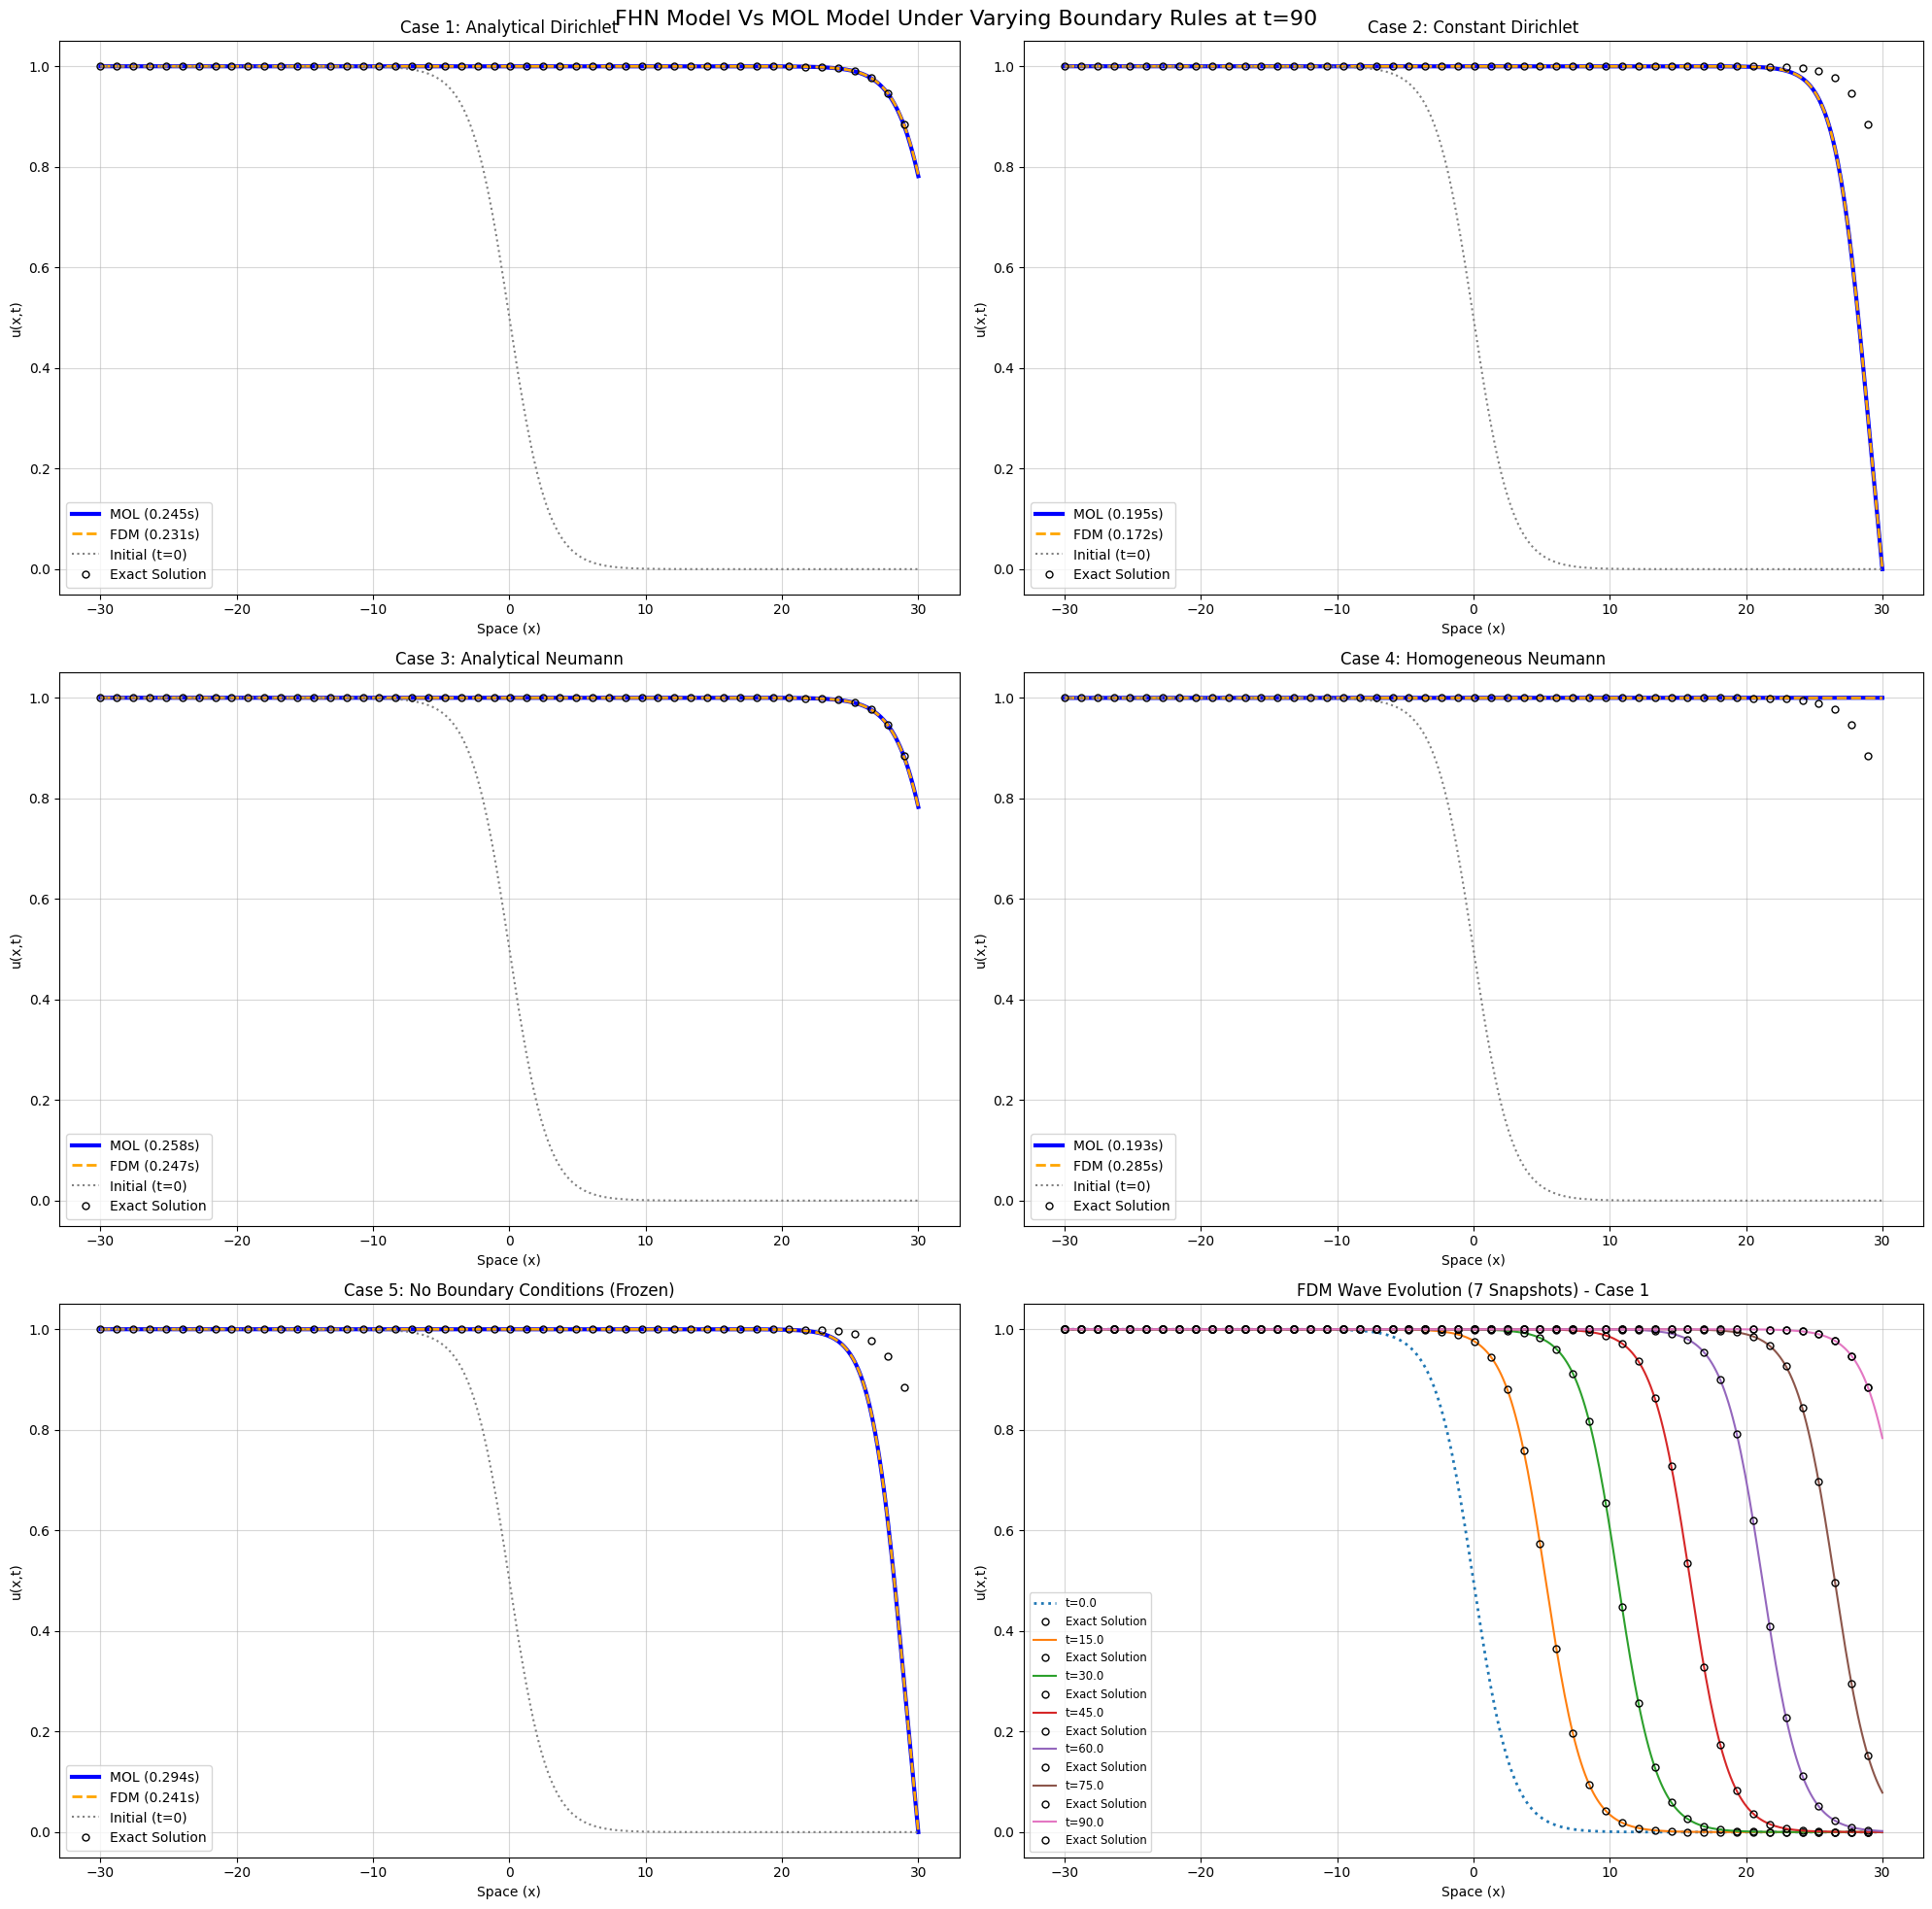

In [14]:
# Create a 3x2 grid of subplots (leaves one empty slot)
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()
plt.suptitle(f"FHN Model Vs MOL Model Under Varying Boundary Rules at t={t_final2}", fontsize=16)
print("Starting simulations...\n")

for ncase in range(1, 6):
    print(f"Processing Case {ncase}: {cases[ncase]}...")

    # ------------------------------------------
    # 1. MOL (Implicit BDF)
    # ------------------------------------------
    mol_sol, mol_time = solve_mol((0, t_final2), [t_final2], ncase)  # We only need the final state for the plot
    mol_times.append(mol_time)
    u_mol_final = mol_sol.y[:, -1]

    # ------------------------------------------
    # 2. FDM (Explicit FTCS)
    # ------------------------------------------
    u_ftcs, fdm_time = run_ftcs(u0, dt, num_steps, ncase)
    fdm_times.append(fdm_time)
    #Exact solution
    u_exact_final2 = exact_solution(x, t_final2, D, a)
     # ------------------------------------------
    # 3. Plotting Subplot
    # ------------------------------------------
    ax = axes[ncase - 1]
    ax.plot(x, u_mol_final, '-', linewidth=3, label=f'MOL ({mol_time:.3f}s)', color='blue')
    ax.plot(x, u_ftcs, '--', linewidth=2, label=f'FDM ({fdm_time:.3f}s)', color='orange')
    ax.plot(x, u0, ':', color='grey', label='Initial (t=0)')
    ax.plot(x, u_exact_final2, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

    ax.set_title(f'Case {ncase}: {cases[ncase]}')
    ax.set_xlabel('Space (x)')
    ax.set_ylabel('u(x,t)')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.5)

# ==========================================
# 6th Subplot: Wave Evolution (FDM Snapshots)
# ==========================================
ax_evol = axes[5]
evol_case = 1  # Select which B.C. case to visualize the evolution for (1 through 5)
ax_evol.set_title(f'FDM Wave Evolution (7 Snapshots) - Case {evol_case}')
ax_evol.set_xlabel('Space (x)')
ax_evol.set_ylabel('u(x,t)')

U_exact = exact_solution(x, t_final2, D, a)

# Plot the first snapshot (Initial Condition at t=0)
ax_evol.plot(x, u0, ':', linewidth=2, label=f't={0.0:.1f}')
ax_evol.plot(x, U_exact, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

# Run a dedicated FDM loop for this subplot to capture intermediate states
for t_label, u_snapshot, u_exact_snapshot in run_ftcs_snapshots(u0, dt, num_steps, evol_case, t_final2):
    # Use a colormap or just standard colors; alpha helps distinguish overlapping waves
    ax_evol.plot(x, u_snapshot, linewidth=1.5, label=f't={t_label:.1f}')
    ax_evol.plot(x, u_exact_snapshot, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

ax_evol.legend(fontsize='small', loc='lower left')
ax_evol.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()



In [15]:
print_execution_time_summary(mol_times, fdm_times)


EXECUTION TIME SUMMARY
Case 1 (Analytical Dirichlet): MOL = 0.2449s  |  FDM = 0.2311s
Case 2 (Constant Dirichlet  ): MOL = 0.1951s  |  FDM = 0.1725s
Case 3 (Analytical Neumann  ): MOL = 0.2579s  |  FDM = 0.2473s
Case 4 (Homogeneous Neumann ): MOL = 0.1926s  |  FDM = 0.2845s
Case 5 (No Boundary Conditions (Frozen)): MOL = 0.2942s  |  FDM = 0.2415s
--------------------------------------------------
AVERAGE MOL TIME: 0.2369 seconds
AVERAGE FDM TIME: 0.2354 seconds


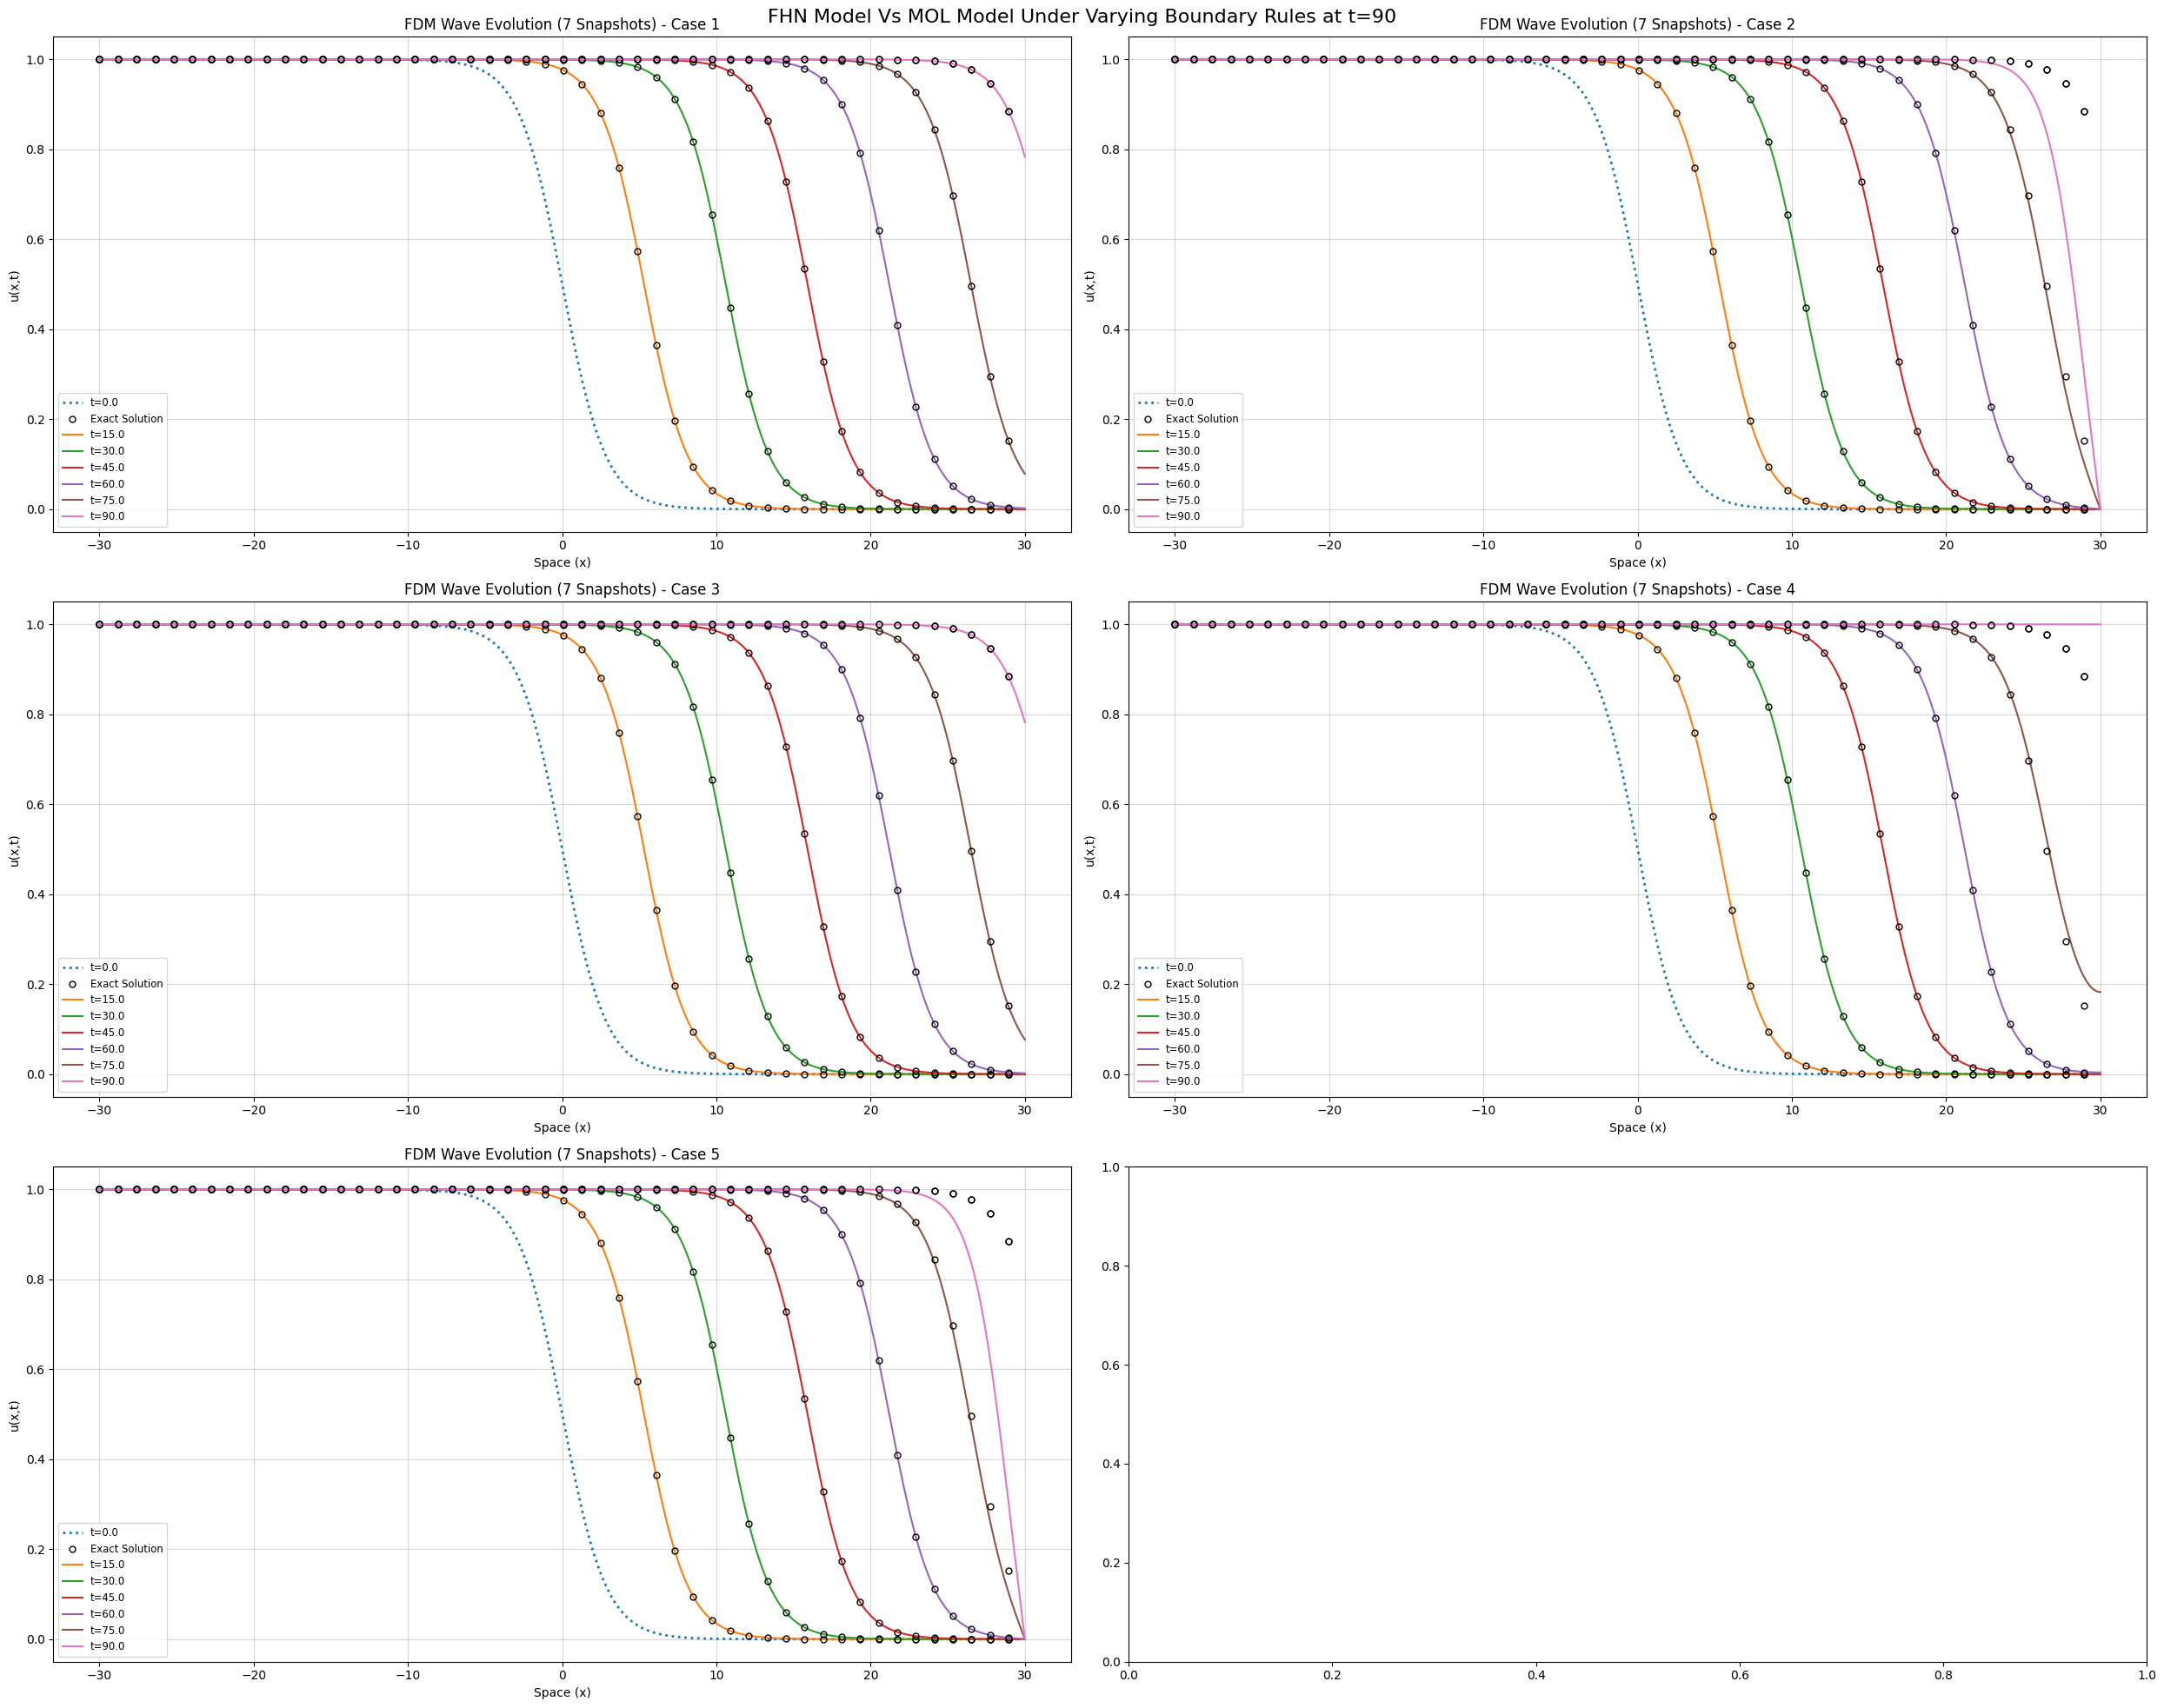

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(25, 20))
axes = axes.flatten()
plt.suptitle(f"FHN Model Vs MOL Model Under Varying Boundary Rules at t={t_final2}", fontsize=16)
# ==========================================
# Subplot: Wave Evolution (FDM Snapshots) for the 5 BC
# ==========================================
for evol_case in range(1, 6):
  ax_evol = axes[evol_case-1]
  ax_evol.set_title(f'FDM Wave Evolution (7 Snapshots) - Case {evol_case}')
  ax_evol.set_xlabel('Space (x)')
  ax_evol.set_ylabel('u(x,t)')

  U_exact = exact_solution(x, t_final2, D, a)

  # Plot the first snapshot (Initial Condition at t=0)
  ax_evol.plot(x, u0, ':', linewidth=2, label=f't={0.0:.1f}')
  ax_evol.plot(x, U_exact, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

  # Run a dedicated FDM loop for this subplot to capture intermediate states
  for t_label, u_snapshot, u_exact_snapshot in run_ftcs_snapshots(u0, dt, num_steps, evol_case, t_final2):
      # Use a colormap or just standard colors; alpha helps distinguish overlapping waves
      ax_evol.plot(x, u_snapshot, linewidth=1.5, label=f't={t_label:.1f}')
      ax_evol.plot(x, u_exact_snapshot, 'ko', markerfacecolor='none', markevery=8, markersize=5)

  ax_evol.legend(fontsize='small', loc='lower left')
  ax_evol.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()



# Crank-Nicelson
The Crank–Nicolson method is a second-order implicit finite difference scheme that averages the diffusion operator between the current and next time level, giving unconditional stability and O(Δt²) accuracy.


In [17]:

def ua_exact(x, t, a, D):
    """Travelling wave solution - eq. (4.2a)."""
    term = np.clip(x / np.sqrt(2*D) + (a - 0.5)*t, -500, 500)
    return 1.0 / (1.0 + np.exp(term))

def uxa_exact(x, t, a, D):
    """Spatial derivative of analytical solution - eq. (4.2b)."""
    term = np.clip(x / np.sqrt(2*D) + (a - 0.5)*t, -500, 500)
    e = np.exp(term)
    return -e * (1.0 / np.sqrt(2*D)) / (1.0 + e)**2


In [18]:
# Simulation parameters (same grid as the rest of the notebook)
a       = 0.25
D       = 1.0
nx      = 400
xl, xu  = -30.0, 30.0
xg      = np.linspace(xl, xu, nx)
dx      = xg[1] - xg[0]
t_final = 20.0
nout    = 7
tout    = np.linspace(0, t_final, nout)

# CN time-step - unconditionally stable, so we use a large dt
dt     = 0.5
Nt     = int(np.ceil(t_final / dt))
dt_act = t_final / Nt
r      = D * dt_act / (2.0 * dx**2)  # CN mesh ratio

print(f'Grid  : nx={nx},  dx={dx:.4f}')
print(f'Time  : Nt={Nt},  dt={dt_act:.4f},  r = {r:.4f}')
print(f'FTCS stability limit: dt <= {dx**2/(2*D):.4f}  =>  CN step is {dt_act/(dx**2/(2*D)):.1f}x larger')


Grid  : nx=400,  dx=0.1504
Time  : Nt=40,  dt=0.5000,  r = 11.0556
FTCS stability limit: dt <= 0.0113  =>  CN step is 44.2x larger


In [19]:
# Build the tridiagonal matrix A in scipy banded storage
# ab[0] = super-diagonal,  ab[1] = main diagonal,  ab[2] = sub-diagonal
N  = nx
ab = np.zeros((3, N))
ab[1, :]  = 1 + 2*r   # main diagonal (1+2r) at every interior node
ab[0, 1:] = -r         # super-diagonal: coupling node i to i+1
ab[2, :-1] = -r        # sub-diagonal:   coupling node i to i-1
# Neumann BC: ghost fold reduces main diagonal from (1+2r) to (1+r) at boundaries
ab[1,  0] = 1 + r      # left  boundary
ab[1, -1] = 1 + r      # right boundary
print('Tridiagonal matrix A built.')
print(f'  Interior diagonal value : {1+2*r:.4f}')
print(f'  Boundary diagonal value : {1+r:.4f}')
print(f'  Off-diagonal value      : {-r:.4f}')


Tridiagonal matrix A built.
  Interior diagonal value : 23.1112
  Boundary diagonal value : 12.0556
  Off-diagonal value      : -11.0556


In [20]:
# Crank-Nicolson time-marching loop
u        = ua_exact(xg, 0.0, a, D)   # IC from eq. (4.1b)
u_cn     = np.zeros((N, nout))
snap_idx = 0
u_cn[:, snap_idx] = u
snap_idx += 1

t_start = time.time()

for n in range(Nt):
    t_now = n * dt_act

    # (a) Reaction term - evaluated EXPLICITLY at current time
    R = u * (1.0 - u) * (a - u)

    # (b) Assemble RHS vector
    b = np.zeros(N)

    # Interior nodes: CN explicit half
    b[1:-1] = (r * u[:-2]
               + (1 - 2*r) * u[1:-1]
               + r * u[2:]
               - dt_act * R[1:-1])

    # Left boundary - Analytical Neumann ghost node from eq. (4.2b)
    ux_L      = uxa_exact(xg[0],  t_now, a, D)
    u_ghost_L = u[1] - 2*dx * ux_L              # ghost node: u[-1] = u[1] - 2dx*ux
    b[0] = ((1 - r)*u[0] + r*u[1]
            + r*(u_ghost_L - u[1])
            - dt_act * R[0])

    # Right boundary - Analytical Neumann ghost node from eq. (4.2b)
    ux_R      = uxa_exact(xg[-1], t_now, a, D)
    u_ghost_R = u[-2] + 2*dx * ux_R             # ghost node: u[N] = u[N-2] + 2dx*ux
    b[-1] = (r*u[-2] + (1 - r)*u[-1]
             + r*(u_ghost_R - u[-2])
             - dt_act * R[-1])

    # (c) Solve tridiagonal system A * u^{n+1} = b  [O(N) Thomas algorithm]
    u = solve_banded((1, 1), ab, b)

    # (d) Store snapshot at output times
    t_next = (n + 1) * dt_act
    if snap_idx < nout and abs(t_next - tout[snap_idx]) < 0.5 * dt_act:
        u_cn[:, snap_idx] = u
        snap_idx += 1

elapsed_cn = time.time() - t_start

u_exact_final = ua_exact(xg, t_final, a, D)
u_cn_final    = u_cn[:, -1]
err_max_cn    = np.max(np.abs(u_cn_final - u_exact_final))
err_rmse_cn   = np.sqrt(np.mean((u_cn_final - u_exact_final)**2))

print(f'CN solver finished : {elapsed_cn:.4f} s  ({Nt} steps)')
print(f'Max absolute error : {err_max_cn:.2e}')
print(f'RMSE               : {err_rmse_cn:.2e}')


CN solver finished : 0.0132 s  (40 steps)
Max absolute error : 4.07e-02
RMSE               : 9.58e-03


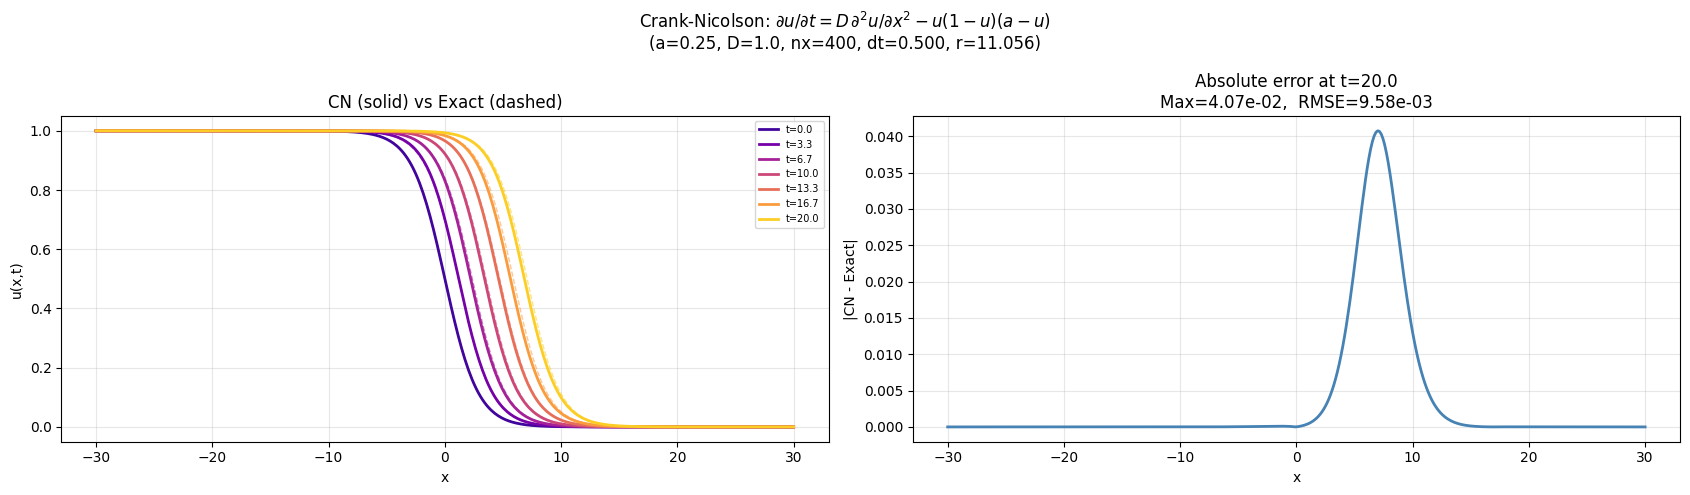

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle(
    r'Crank-Nicolson: $\partial u/\partial t = D\,\partial^2 u/\partial x^2 - u(1-u)(a-u)$'
    f'\n(a={a}, D={D}, nx={nx}, dt={dt_act:.3f}, r={r:.3f})',
    fontsize=12
)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, nout))

# Snapshot curves
ax = axes[0]
for it in range(nout):
    ax.plot(xg, u_cn[:, it],                  color=colors[it], lw=2,  label=f't={tout[it]:.1f}')
    ax.plot(xg, ua_exact(xg, tout[it], a, D), color=colors[it], lw=1,  ls='--', alpha=0.55)
ax.set_xlabel('x');  ax.set_ylabel('u(x,t)')
ax.set_title('CN (solid) vs Exact (dashed)')
ax.legend(fontsize=7);  ax.grid(True, alpha=0.3)

# Absolute error
ax = axes[1]
ax.plot(xg, np.abs(u_cn_final - u_exact_final), color='steelblue', lw=2)
ax.set_xlabel('x');  ax.set_ylabel('|CN - Exact|')
ax.set_title(f'Absolute error at t={t_final}\nMax={err_max_cn:.2e},  RMSE={err_rmse_cn:.2e}')
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('cn_results.png', dpi=150, bbox_inches='tight')
plt.show()


#Operator Splitting via Matrix Exponential (Exact Linear Propagator)


**The Reaction-Diffusion System**

The FitzHugh-Nagumo (FHN) model is governed by a stiff, non-linear reaction-diffusion Partial Differential Equation (PDE) of the form:


$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} + \mathcal{R}(u)$$


where $D$ is the diffusion coefficient and $\mathcal{R}(u) = -u(1-u)(a-u)$ is the non-linear cubic reaction kinetics. Numerical integration of this system is challenging because the diffusion term introduces severe stability constraints (dictated by the Courant-Friedrichs-Lewy or CFL condition,how large the time step can be), while the reaction term dictates the local non-linear dynamics.

**1.2. Strang Operator Splitting**

To efficiently solve this, we employ **Strang Splitting**, which decouples the PDE into a  diffusion problem and a  reaction problem. For a time step $\Delta t$, the state vector $u(x,t)$ is updated via a symmetric sequence of operators to achieve second-order accuracy in time, $\mathcal{O}(\Delta t^2)$:


$$u(t + \Delta t) \approx \mathcal{S}_{\mathcal{R}}(\Delta t / 2) \circ \mathcal{S}_{\mathcal{D}}(\Delta t) \circ \mathcal{S}_{\mathcal{R}}(\Delta t / 2) u(t)$$


where $\mathcal{S}_{\mathcal{R}}$ is the numerical solution to the reaction Ordinary Differential Equation (ODE) and $\mathcal{S}_{\mathcal{D}}$ is the solution to the diffusion PDE.

**1.3. Exact Linear Propagator (Matrix Exponential)**

For the pure diffusion step, spatial discretization using second-order central finite differences reduces the PDE to a system of linear ODEs:


$$\frac{d\mathbf{u}}{dt} = \mathbf{L} \mathbf{u}$$


where $\mathbf{L}$ is the discretized spatial Laplacian matrix scaled by $D / \Delta x^2$, modified appropriately to encapsulate the boundary conditions.

Because $\mathbf{L}$ is a constant matrix (time-invariant), the system admits an exact analytical solution via the matrix exponential:


$$\mathbf{u}(t + \Delta t) = e^{\mathbf{L} \Delta t} \mathbf{u}(t) = \mathbf{P} \mathbf{u}(t)$$


Here, $\mathbf{P} = e^{\mathbf{L} \Delta t}$ acts as an exact linear propagator. Multiplying the spatial vector $\mathbf{u}$ by $\mathbf{P}$ advances the diffusion process forward in time without introducing any time-discretization error.

---

**2. Implementation Methodology**

The algorithm was implemented in Python using the `scipy.linalg.expm` function and integrates the mathematical theory through the following distinct phases:

1. **Matrix Construction ($\mathbf{L}$):** Prior to the temporal loop, a sparse-equivalent tridiagonal matrix is constructed. For Dirichlet boundaries (fixed values), the boundary rows are zeroed out to prevent the internal matrix from inherently modifying the edge nodes. For Neumann boundaries (fixed flux), the ghost-node reflection method is explicitly baked into the first and last rows of the matrix (e.g., coefficients of $-2$ and $+2$).
2. **Propagator Pre-computation ($\mathbf{P}$):** The matrix exponential $\mathbf{P} = \exp(\mathbf{L} \Delta t)$ is computed exactly once.
3. **Complex Domain Projection:** Due to finite floating-point precision, calculating the exponential of an ill-conditioned or asymmetric matrix (arising from Neumann boundary conditions) generates negligible imaginary artifacts (e.g., $+ 10^{-16}j$). If passed into the non-linear RK4 reaction term, these artifacts grow exponentially, causing the numerical solution to blow up to `NaN`. This is resolved by enforcing a strict real-domain projection using `np.real(expm(...))`.
4. **Integration Loop:** * **Half-Step Reaction:** Advanced using explicit 4th-Order Runge-Kutta (RK4).
* **Full-Step Diffusion:** Evaluated via a highly optimized matrix-vector multiplication ($\mathbf{u}^* = \mathbf{P} \mathbf{u}$). Missing explicit boundary values or external source terms are then injected manually to correct the boundary nodes.
* **Half-Step Reaction:** Advanced again using RK4.



---

**3. Advantages of the Technique**

* **Absolute Temporal Exactness for Diffusion:** Unlike explicit finite differences (FTCS) or implicit methods (Backward Euler/BDF) which approximate the time derivative using Taylor expansions, the matrix exponential solves the linear temporal component analytically. The time-discretization error for the diffusion operator is strictly zero.
* **Unconditional Stability & Amplified Step Sizes:** Explicit solvers require $\Delta t \le \Delta x^2 / (2D)$ to remain stable. The matrix exponential is unconditionally stable, allowing for integration step sizes that are orders of magnitude larger (e.g., $\Delta t = 0.5$ vs. $\Delta t = 0.01$). The maximum allowable step size is limited only by the timescale of the non-linear reaction term and the desired splitting error tolerance.
* **Low Loop Overhead:** By pre-computing $\mathbf{P}$, the computational burden during the simulation loop is reduced to a single $\mathcal{O}(N^2)$ matrix-vector multiplication per step, bypassing the need to iteratively invert matrices or call complex ODE solvers at every temporal increment.

---

**4. Disadvantages and Limitations**

* **Loss of Sparsity:** While the finite difference matrix $\mathbf{L}$ is highly sparse (tridiagonal), its exponential $\mathbf{P} = e^{\mathbf{L} \Delta t}$ is a fully dense matrix. Every node in the domain technically influences every other node over time $\Delta t$.
* **Computational Complexity of Pre-computation:** Computing the matrix exponential generally scales as $\mathcal{O}(N^3)$, where $N$ is the number of spatial grid points. While trivial for a 1D grid of $N=400$, this becomes computationally prohibitive for high-resolution 2D or 3D domains (e.g., a $100 \times 100 \times 100$ grid yields a matrix of size $10^6 \times 10^6$).
* **Memory Constraints:** Because $\mathbf{P}$ is dense, storing it requires $\mathcal{O}(N^2)$ memory. For multi-dimensional problems, this rapidly exceeds the RAM capacity of standard workstations.
* **Splitting Error Remains:** While the diffusion step is solved exactly, the Strang Splitting technique itself still incurs a time-discretization error of $\mathcal{O}(\Delta t^2)$ because the reaction and diffusion physical phenomena occur simultaneously in reality, not sequentially. If $\Delta t$ is increased too aggressively, the splitting error will dominate, leading to inaccurate wave velocities or shapes, despite the numerical scheme remaining perfectly stable.

Starting Comparative Simulations...

Processing Case 1...
 -> MOL: 0.0564s | Matrix Exp: 0.1093s
Processing Case 2...
 -> MOL: 0.0942s | Matrix Exp: 0.1001s
Processing Case 3...
 -> MOL: 0.1197s | Matrix Exp: 0.0727s
Processing Case 4...
 -> MOL: 0.0593s | Matrix Exp: 0.0965s
Processing Case 5...
 -> MOL: 0.1340s | Matrix Exp: 0.0722s


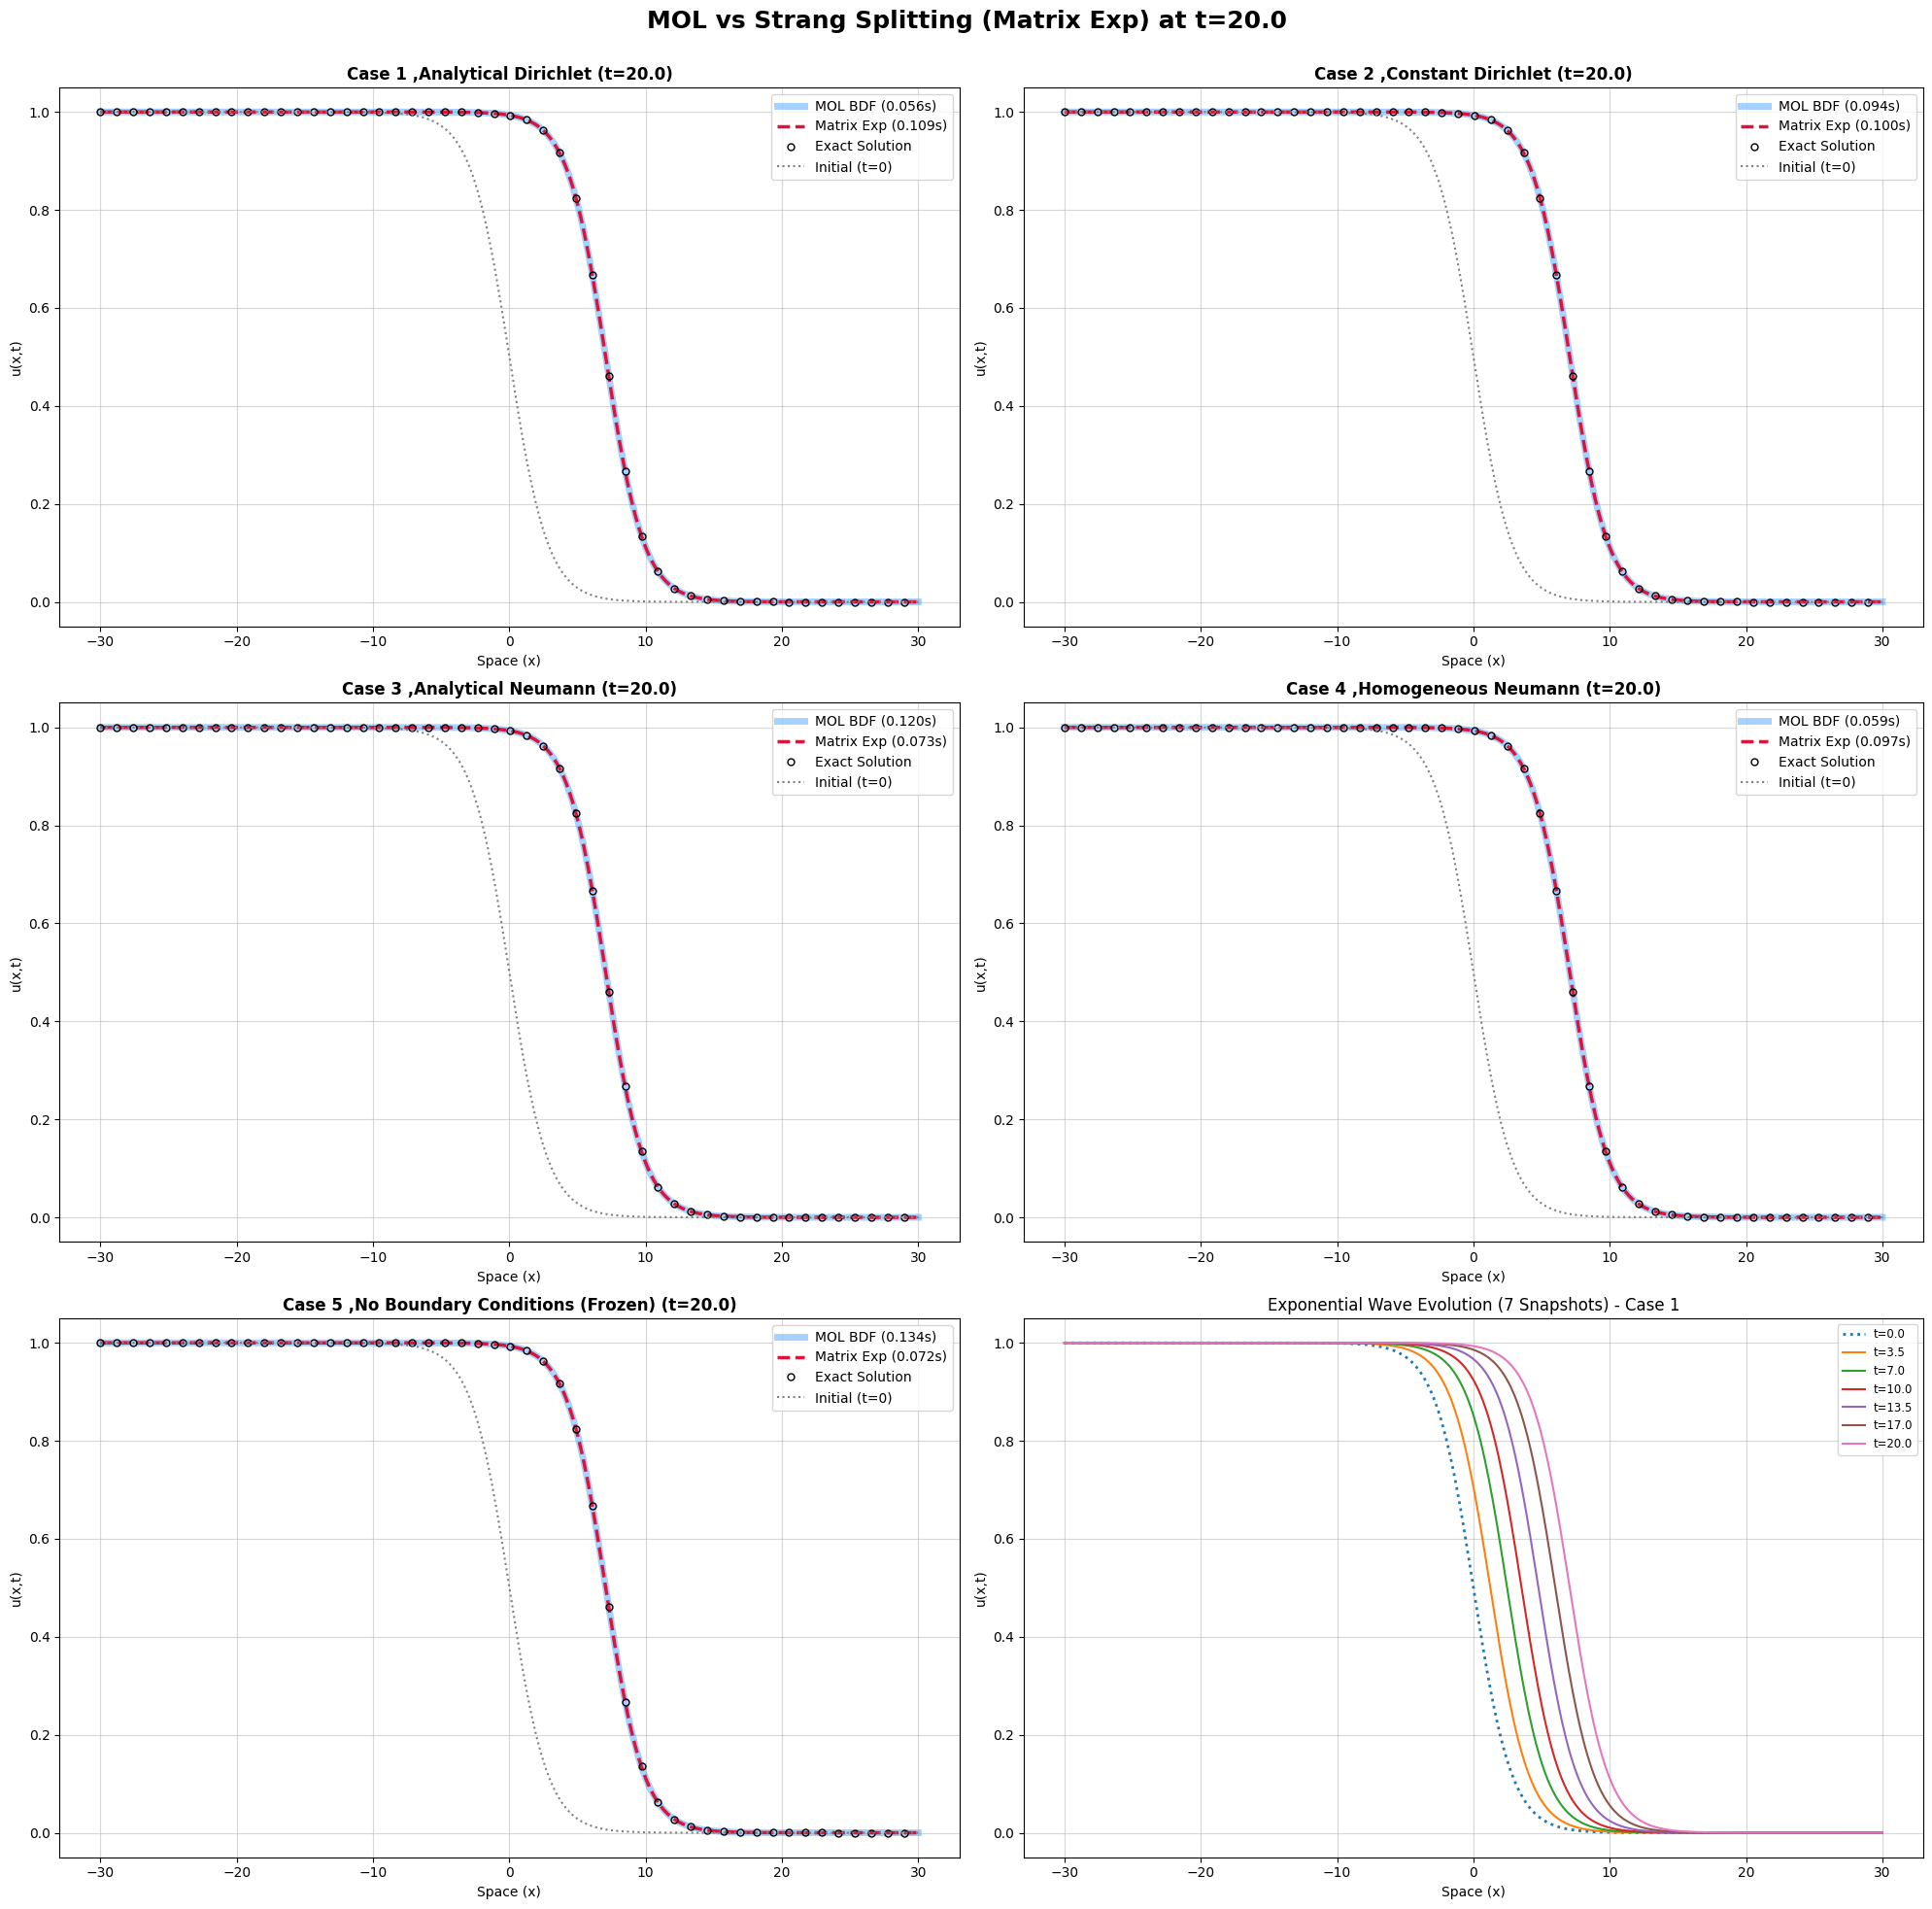

In [22]:
from scipy.linalg import expm
from scipy.integrate import solve_ivp

# ==========================================
# 1. Strang Splitting (Matrix Exponential) Setup
# ==========================================
def reaction_rk4(u_val, dt_step):
    """Explicit RK4 for the local reaction term."""
    def f(u_tmp): return -u_tmp * (1.0 - u_tmp) * (a - u_tmp)
    k1 = f(u_val)
    k2 = f(u_val + 0.5 * dt_step * k1)
    k3 = f(u_val + 0.5 * dt_step * k2)
    k4 = f(u_val + dt_step * k3)
    return u_val + (dt_step / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

dt_strang = 0.5
num_steps_strang = int(np.ceil(t_final / dt_strang))

def build_propagator(nx, D, dx, dt_step, ncase):
    """Constructs the exact linear propagator P = exp(L * dt)."""
    L = np.zeros((nx, nx))
    for i in range(1, nx-1):
        L[i, i-1] = 1.0
        L[i, i]   = -2.0
        L[i, i+1] = 1.0

    if ncase in [1, 2, 5]:
        L[0, :] = 0
        L[-1, :] = 0
    elif ncase in [3, 4]:
        L[0, 0], L[0, 1] = -2.0, 2.0
        L[-1, -2], L[-1, -1] = 2.0, -2.0

    L = (D / dx**2) * L
    return np.real(expm(L * dt_step))

# ==========================================
# 2. Execution Setup & Plot Formatting
# ==========================================
exp_times = []
mol_times_for_comparison = []

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()
plt.suptitle(f"MOL vs Strang Splitting (Matrix Exp) at t={t_final}", fontsize=18, fontweight='bold')

u_exact_final = exact_solution(x, t_final, D, a)
t_snapshots = np.linspace(0, t_final, 7)
evol_case = 1

ax_evol = axes[5]
ax_evol.set_title(f'Exponential Wave Evolution (7 Snapshots) - Case {evol_case}')
ax_evol.set_xlabel('Space (x)')
ax_evol.set_ylabel('u(x,t)')
ax_evol.plot(x, u0.copy(), ':', linewidth=2, label=f't={0.0:.1f}')

print(f"Starting Comparative Simulations...\n")

# ==========================================
# 3. Main Split Loop
# ==========================================
for ncase in range(1, 6):
    print(f"Processing Case {ncase}...")

    # ------------------------------------------
    # A. RUN MOL (For direct comparison)
    # ------------------------------------------
    mol_sol, mol_time = solve_mol((0, t_final), [t_final], ncase)
    mol_times_for_comparison.append(mol_time)
    u_mol_final = mol_sol.y[:, -1]

    # ------------------------------------------
    # B. RUN STRANG SPLITTING
    # ------------------------------------------
    start_exp = time.time()
    Propagator = build_propagator(nx, D, dx, dt_strang, ncase)
    u_strang = u0.copy()
    snapshot_idx = 1

    for n in range(num_steps_strang):
        t_current = n * dt_strang
        t_next = t_current + dt_strang

        # Step 1: Half Reaction
        u_star = reaction_rk4(u_strang, dt_strang / 2.0)
        # Step 2: Full Diffusion
        u_star_star = Propagator @ u_star

        # Explicit Boundary Values
        if ncase == 1:
            term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * t_next
            u_star_star[0] = 1.0 / (1.0 + np.exp(term_L))
            term_R = x[-1] / np.sqrt(2*D) + (a - 0.5) * t_next
            u_star_star[-1] = 1.0 / (1.0 + np.exp(term_R))
        elif ncase == 2:
            u_star_star[0] = 1.0
            u_star_star[-1] = 0.0
        elif ncase == 5:
            u_star_star[0] = u0[0]
            u_star_star[-1] = u0[-1]

        # Step 3: Half Reaction
        u_strang = reaction_rk4(u_star_star, dt_strang / 2.0)

        # Snapshots
        if ncase == evol_case and snapshot_idx < 7 and t_next >= t_snapshots[snapshot_idx]:
            ax_evol.plot(x, u_strang.copy(), linewidth=1.5, label=f't={t_next:.1f}')
            snapshot_idx += 1

    exp_time = time.time() - start_exp
    exp_times.append(exp_time)
    print(f" -> MOL: {mol_time:.4f}s | Matrix Exp: {exp_time:.4f}s")

    # ------------------------------------------
    # C. PLOTTING THE LAYERED COMPARISON
    # ------------------------------------------
    ax = axes[ncase - 1]

    # Layer 1: MOL (Thicker, semi-transparent blue)
    ax.plot(x, u_mol_final, '-', linewidth=5, alpha=0.4, label=f'MOL BDF ({mol_time:.3f}s)', color='dodgerblue')

    # Layer 2: Matrix Exp (Dashed crimson, sits inside the thick blue line)
    ax.plot(x, u_strang, '--', linewidth=2.5, label=f'Matrix Exp ({exp_time:.3f}s)', color='crimson')

    # Layer 3: Exact Solution (Open circles)
    ax.plot(x, u_exact_final, 'ko', markerfacecolor='none', markevery=8, markersize=5, label='Exact Solution')

    # Layer 4: Initial
    ax.plot(x, u0, ':', color='grey', label='Initial (t=0)')

    ax.set_title(f'Case {ncase} ,{cases[ncase]} (t={t_final})', fontweight='bold')
    ax.set_xlabel('Space (x)')
    ax.set_ylabel('u(x,t)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.5)

# Finalize 6th Subplot
ax_evol.legend(fontsize='small', loc='upper right')
ax_evol.grid(True, alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

# 5. Comprehensive Analysis & Side-by-Side Comparison

This section performs a complete benchmarking and error analysis across the three numerical techniques introduced above:
1. **Method of Lines (MOL)** with an implicit Adaptive BDF solver.
2. **Fully Discrete Finite Difference Method (FTCS)** with a conditionally stable explicit step.
3. **Crank-Nicelson**

We compare them against the exact analytical traveling wave solution at $t=20$ to assess accuracy, efficiency (execution time), and total time steps taken.

In [23]:
# Define target final time and exact solution for benchmarking
t_final = 20.0
u_exact_final = exact_solution(x, t_final, D, a)

# Run all methods to collect results
# MOL
sol_mol, time_mol = solve_mol((0, t_final), [t_final], 1)
u_mol = sol_mol.y[:, -1]
steps_mol = sol_mol.nfev

# Explicit FTCS
dt_ftcs, steps_ftcs = ftcs_step_params(t_final)
u_ftcs, time_ftcs = run_ftcs(u0, dt_ftcs, steps_ftcs, 1)

# Strang Splitting
dt_strang = 0.5
steps_strang = int(np.ceil(t_final / dt_strang))
start = time.time()
Propagator = build_propagator(nx, D, dx, dt_strang, 1)
u_strang = u0.copy()
for n in range(steps_strang):
    t_n = n * dt_strang
    u_s = reaction_rk4(u_strang, dt_strang / 2.0)
    u_ss = Propagator @ u_s
    # Apply Dirichlet for analytical comparison
    term_L = x[0] / np.sqrt(2*D) + (a - 0.5) * (t_n + dt_strang)
    u_ss[0] = 1.0 / (1.0 + np.exp(term_L))
    u_strang = reaction_rk4(u_ss, dt_strang / 2.0)
time_strang = time.time() - start

In [24]:

# 3. Compute Metrics
results = [
    (u_mol, time_mol, steps_mol),
    (u_ftcs, time_ftcs, steps_ftcs),
    (u_cn_final, elapsed_cn, Nt),
    (u_strang, time_strang, steps_strang),
]
#print(len(results))
#print(type(results))
names = ['MOL (BDF)', 'Explicit FTCS', 'Crank-Nicolson' , 'Strang Splitting']
stability=['Unconditional','dt <= dx^2/(2*D)' ,'Unconditional','Unconditional']
method_type=['Implicit' ,'Explicit' , 'Implicit', 'Implicit']
time_order=['Adaptive', 'O(dt)', 'O(dt^2)', 'O(dt^2)']

# 4. Generate DataFrame
epsilon = 1e-10 # Safeguard against division by zero where the wave profile hits 0.0

df = pd.DataFrame({
    'Method': names[0:3] ,
    'Method Type': method_type[0:3],
    'Stability': stability[0:3],
    'Time Order':   time_order[0:3],
    'Execution Time (s)': [r[1] for r in results[0:3]],
    'Total Steps': [r[2] for r in results[0:3]],
    'Max Abs Error': [np.max(np.abs(r[0] - u_exact_final)) for r in results[0:3]],
    'RMSE Error': [np.sqrt(np.mean((r[0] - u_exact_final)**2)) for r in results[0:3]],

    # NEW: Average True Percent Error Calculation
    'Avg True Error (%)': [np.mean(np.abs((u_exact_final - r[0]) / (np.abs(u_exact_final) + epsilon))) * 100 for r in results[0:3]]
})

print(df.to_string(index=False))


        Method Method Type        Stability Time Order  Execution Time (s)  Total Steps  Max Abs Error  RMSE Error  Avg True Error (%)
     MOL (BDF)    Implicit    Unconditional   Adaptive            0.074908           44       0.000515    0.000111            0.284679
 Explicit FTCS    Explicit dt <= dx^2/(2*D)      O(dt)            0.068054         1966       0.000346    0.000076            0.048651
Crank-Nicolson    Implicit    Unconditional    O(dt^2)            0.013160           40       0.040732    0.009583            5.153087


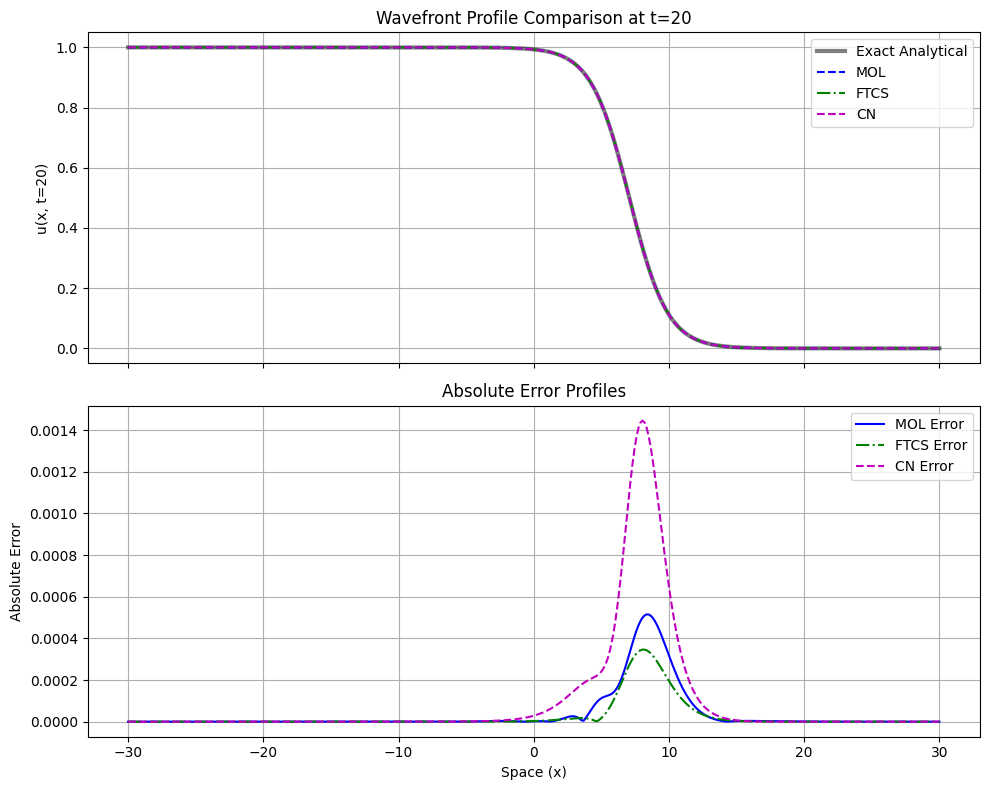

In [25]:

# 5. Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(x, u_exact_final, 'k-', linewidth=3, label='Exact Analytical', alpha=0.5)
axes[0].plot(x, results[0][0], 'b--', label='MOL')
axes[0].plot(x, results[1][0], 'g-.', label='FTCS')
#axes[0].plot(x, results[2][0], 'r:', label='Strang')
axes[0].plot(x, results[3][0], 'm--', label='CN')
axes[0].set_ylabel('u(x, t=20)')
axes[0].set_title('Wavefront Profile Comparison at t=20')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x, np.abs(results[0][0] - u_exact_final), 'b-', label='MOL Error')
axes[1].plot(x, np.abs(results[1][0] - u_exact_final), 'g-.', label='FTCS Error')
#axes[1].plot(x, np.abs(results[2][0] - u_exact_final), 'r:', label='Strang Error')
axes[1].plot(x, np.abs(results[3][0] - u_exact_final), 'm--', label='CN Error')
axes[1].set_ylabel('Absolute Error')
axes[1].set_xlabel('Space (x)')
#axes[1].set_yscale('log') # Log scale for error is usually more informative
axes[1].set_title('Absolute Error Profiles')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()